<div style="background: linear-gradient(135deg, #e9f2fb 0%, #f7fbff 100%); padding: 18px 20px; border: 1px solid #d5e3f0; border-radius: 10px; text-align: center;">
  <div style="font-size: 32px; font-weight: 700; color: #1f3b57; letter-spacing: 0.2px;">NX-414 Brain-like Computation and Intelligence</div>
</div>


<div style="text-align: center; font-size: 21px; font-weight: 600; color: #36536b; margin-top: 6px;">Project Notebook — Spring 2026</div>


<div style="text-align: center; color: #4f6478; font-size: 16px; margin-bottom: 10px;">Brain–Model Alignment Across Neural Recording Modalities</div>
<div style="text-align: center; color: #6b7280; font-size: 13px;">Prepared by: Abdulkadir Gokce</div>

---


# Group Information

Fill in this section at the top of your notebook and report.

- **Group member 1:** Full name, SCIPER number, email address  
- **Group member 2:** Full name, SCIPER number, email address  
- **Group member 3 (if applicable):** Full name, SCIPER number, email address  

---

# What You Must Submit

Submit the following files:

1. **One Jupyter notebook** containing your full analysis.
2. **Any supporting Python scripts** needed to run the notebook.
3. **Figures that are part of your notebook answers** should be embedded and rendered in notebook Markdown.
4. **One PDF report** of **up to 2 pages**, **excluding references**, with **no appendix**.
5. **One zip archive** named exactly as:

```text
nx414_{SCIPER1}_{SCIPER2}_{SCIPER3}.zip
```

If your group has fewer than three members, reduce the number of `_SCIPER` fields accordingly.

## Submission Rules

- **Clear all notebook outputs before submission.**
- If outputs are not cleared, we will clear them ourselves and grade the cleaned notebook.
- Submit only the code required to reproduce your results.
- **Do not submit model weights.**
- **Do not submit CSV files or other large derived result dumps.**
- Keep the archive lightweight and reproducible.
- For the **final notebook**, any figure you want to present as part of your scientific argument should be **embedded in Markdown with accompanying interpretation**, rather than left as a raw cell output with no explanation.

Failure to follow these instructions may reduce your final grade.

## Use of LLMs

You may use LLM-based tools to help you write code, debug, or improve explanations. However, you remain fully responsible for the **correctness**, **quality**, and **clarity** of everything you submit, including both the notebook and the report.

In particular:

- check that any generated code actually runs and does what you claim it does,
- verify that any scientific statement or interpretation is correct,
- make sure the final writing sounds like a clear academic report written for this course,
- avoid vague, overly polished, or context-free text,
- avoid fancy wording or unnecessarily complex sentences that do not add clarity.

If you use an LLM, revise the output so that your submission reads naturally, is specific to your actual results, and does not look like generic generated text.

Failure to do so may result in **a point deduction**.

## Expected scope

Because this project spans roughly **three weeks** and counts for **30% of the final course grade**, the expected output is closer to a **compact course project** than to a one-week homework notebook. Your submission should therefore read like a small empirical study: it should be clearly structured, contain short written interpretations throughout, compare alternatives systematically, and end with a coherent synthesis of your main findings.

A strong notebook will not only run end-to-end, but will also explain **why** each analysis is being performed, what each metric is meant to capture, and what the results imply about the strengths and limitations of the models and datasets.

At the same time, **some parts of the project are intentionally left a bit loose**. This is by design: beyond implementing the required core analyses, you are expected to make reasonable scientific choices, justify them clearly, and show some ingenuity in how you explore the data and compare models.

## Suggested 3-week pacing

Use the notebook structure below to organize your work over the three weeks.

- **Week 1:** complete **Section 0** and **Section 1**. Understand the datasets, verify stimulus matching, inspect the processed responses, and start the visualization and reliability analyses.
- **Week 2:** complete the required analyses in **Section 2**. In this section, you must complete both the representational and predictive parts of the project. Begin **Section 3** by brainstorming possible extensions and sketching out a plan for your chosen extension.
- **Week 3:** complete **Section 3**, polish the notebook, select the strongest figures, and write the 2-page report.


---

# 0. Introduction and Setup

## 0.1 Project goal

In this project, you will study how neural responses from different recording modalities align with features extracted from two vision models. More specifically, you will work in the standard **brain–model alignment** setting: a model processes an image, a candidate internal layer is selected, and that representation is compared to measured neural responses using representational and predictive metrics.

The notebook is organized around four sections:

- **Section 0:** introduction, setup, and understanding the provided resources.
- **Section 1:** dataset inspection, visualization, and noise ceiling estimation.
- **Section 2:** brain–model alignment through both representational metrics and predictive linear models.
- **Section 3:** an open-ended extension beyond the baseline pipeline.

## 0.2 Why task-optimized models?

Task-optimized neural networks are among the most useful current **in-silico models of sensory cortex**. The central idea is simple: instead of hand-designing a model to mimic every biological detail, we optimize a model to perform a meaningful visual task and then ask whether its internal representations resemble those found in the brain. This approach has been highly influential because models trained to solve vision tasks often develop representations that predict activity along the visual hierarchy surprisingly well.

These models are useful scientifically because they provide **testable computational hypotheses**. If a model layer predicts neural responses well, that does not mean the brain literally implements the same mechanism, but it does suggest that the layer may encode information in a similar format or at a similar level of abstraction. Brain–model alignment is therefore a way to ask not just whether a model is accurate on a task, but whether it organizes visual information in a brain-relevant way.

## 0.3 Why compare multiple modalities?

A single recording modality gives only a partial view of neural computation. In this project, you will work with **electrophysiology, EEG, and fMRI**, which differ in temporal resolution, spatial resolution, and what exactly is measured. Looking across modalities helps you see which conclusions are robust and which depend on the measurement scale.

## 0.4 Learning goals

By the end of this project, you should be able to:

- inspect and summarize neural datasets from multiple modalities,
- visualize neural signals and data quality,
- implement and compare **two noise ceiling estimators**,
- implement **RSA** and **unbiased linear CKA**,
- fit **linear encoding models** from model features to neural responses,
- compare alignment across **models, layers, ROIs, and metrics**,
- interpret what each alignment metric captures,
- design and evaluate one meaningful extension beyond the baseline pipeline.

A strong submission should therefore demonstrate both **technical correctness** and **scientific reasoning**: beyond obtaining scores, you should be able to explain why a dataset is noisy, why one layer may outperform another, and why representational and predictive metrics sometimes disagree.

## 0.5 Provided data

All main data are stored in `/shared/NX-414/data/`.

### Background: processed data derivatives

The files provided for this project are **not raw neural recordings**. They are already processed, analysis-ready derivatives produced with modality-appropriate pipelines. This is important scientifically: many of your results will depend not only on the model features, but also on preprocessing choices such as repetition averaging, denoising, response-window selection, voxel/channel filtering, and how reliability is estimated.

We performed the preprocessing for you because these pipelines often require substantial modality-specific expertise, time, and compute.

At a high level, the datasets used here were prepared as follows:

- **TVSD (macaque electrophysiology)** — normalized multi-unit responses from ventral-stream areas. Responses were z-scored within session, firing rates were averaged in an analysis window centered on each site’s response peak, low-reliability channels were excluded, and repeated test responses were averaged for evaluation.
- **THINGS-EEG2 (human EEG)** — source EEG responses resampled to **100 Hz**. Noise ceilings were computed per subject, channel, and time point, and repetitions were averaged within train and test splits.
- **NSD (human fMRI)** — **b3 single-trial beta estimates** in `func1pt8mm` space, derived using voxel-wise HRF fitting, GLMdenoise, and ridge regression. Analyses are restricted to ROI-defined visually responsive voxels, low-reliability voxels are filtered out, and responses are averaged across available repetitions.

You are **not** expected to re-run the full preprocessing pipelines. You **are** expected to understand what kinds of neural quantities you are analyzing, what has already been averaged or denoised, and how these choices affect interpretation.

### Main neural datasets

- **`tvsd.h5`** — macaque electrophysiology from **2 monkeys**, with **22,248 train** and **100 test** stimuli, covering **V1, V4, and IT**.
- **`things_eeg2.h5`** — human EEG from **10 subjects**, with **16,540 train** and **200 test** stimuli, with region groupings such as **occipital**, **parietal**, **temporal**, **frontal**, **central**, **occipital_parietal**, and **whole_brain**.
- **`nsd_func1pt8mm_individualROIs.h5`** — human fMRI from **8 subjects**, with roughly **9,000 train** and **1,000 test** stimuli per subject, across multiple visual ROIs.

### Additional files

- `things_eeg2-test_reps.h5`  
  EEG test responses **with repetitions and without averaging**.  
  Use this file to implement and compare **two noise ceiling estimators**.

- `nsd-subj01-ncsnr-{lh,rh}.mgh`  
  Surface-based NSD reliability values for `subj-01` on **fsaverage**.  
  Use these to visualize cortical reliability and convert **ncsnr** into **noise ceiling**.

### Neural response shapes

- **TVSD:** `(n_stimuli, n_units)`
- **EEG2:** `(n_stimuli, n_channels, n_timepoints)`
- **NSD:** `(n_stimuli, n_voxels)`

For EEG, the time axis contains **80 time points** sampled at **100 Hz**, covering **0.0 s to 0.8 s**.

### Noise ceilings

Noise ceilings are stored per target:

- per neuron for **TVSD**,
- per channel × time point for **EEG2**,
- per voxel for **NSD**.

They are stored as **percent reliability**.  
To convert them to the range `[0, 1]`, divide by `100`.

In this project, the provided noise ceilings are mainly intended for **predictive metrics** such as **Pearson correlation** and **explained variance**. They reflect the reliability of the neural responses and therefore define an upper bound on how well any model can predict those responses.

When you compute predictive metrics, you should apply a noise ceiling correction to account for this upper bound. The standard idea is simple: divide the raw predictive score by the corresponding noise ceiling value for that target.

The provided noise ceilings are defined for **explained variance**. If you want to apply the same logic to **Pearson correlation**, first convert the explained-variance ceiling into a correlation ceiling by taking the element-wise square root, and then divide the raw correlation by that quantity. For a more detailed discussion of noise ceiling correction, see van Bree et al. (2025).

You may therefore report both **raw** and **noise-ceiling-corrected** predictive scores where appropriate.


For example, if the provided ceiling is an explained-variance reliability estimate, you can compute a noise-corrected Pearson correlation as:

```python
r_nc = r / np.sqrt(ev_ceiling)
```

where `r` is the raw Pearson correlation and `ev_ceiling` is the explained-variance ceiling expressed on the range `[0, 1]`.

By contrast, **RSA** and **CKA** should typically be reported as **raw values** in this project. Noise ceilings for representational similarity metrics require a different methodology and are **not** provided here.


Do **not** apply this correction directly to **RSA** or **CKA**.

### Stimulus identifiers

- **TVSD / EEG2:** byte strings such as `b'aardvark/aardvark_01b.jpg'`
- **NSD:** integer stimulus IDs

## 0.6 Model features

All extracted features are stored in `/shared/NX-414/extracted_features/`.

The feature files contain **internal activations extracted from multiple candidate layers** while the models process the same images shown in the neural experiments. You can think of each layer as a representation matrix of shape roughly **stimuli × features**. These layer-wise representations are what you will compare to the brain using RSA, CKA, and encoding models.

Feature extractions across models were made tractable by projecting activations to **30,000 dimensions** using a random projection. The provided feature files follow that same idea. In practice, this means you can treat the feature vectors as compact surrogates for the original activations while still performing meaningful alignment analyses.

### Model A: `adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0`

- Architecture: **ResNet-152**
- Pretraining: ImageNet + adversarial fine-tuning
- Available feature files:
  - `things_stimuli.h5`
  - `nsd_stimuli.h5`

### Model B: `Qwen3-VL-2B-Instruct`

- Architecture: **vision-language transformer**
- Available feature files:
  - `things_stimuli.h5`
  - `nsd_stimuli.h5`

For both models, layers have been projected to **30,000 dimensions** using random projections.

### Feature extraction note

For this project, feature extraction has already been done for you. Your job is therefore not to run the vision models on raw images, but to understand **which layer** to use, how to match feature rows to neural stimuli, and what different layers reveal about representational hierarchy.

### Important note for NSD

For NSD, the feature files contain features for **all 73,000 images**, but each subject saw only a subset (~9,000).  
You must therefore select feature rows using the subject-specific NSD stimulus IDs.

## 0.7 Matching features to neural responses

You must match neural responses and features through the stimulus IDs.

### THINGS-based datasets: TVSD and EEG2

For these datasets, both neural IDs and feature IDs are byte strings. Matching should therefore be exact.

### NSD

For NSD, both sides use integer IDs. The feature file contains all 73,000 stimuli, while each subject has only a subset. Use the subject-specific NSD stimulus IDs to select the corresponding feature rows.

### Recommended procedure

```python
feat_ids = feature_file['ids'][:]
id_to_feat_idx = {id_: i for i, id_ in enumerate(feat_ids)}
feat_idx = np.array([id_to_feat_idx[x] for x in neural_ids])
```

To make HDF5 reads efficient:

1. build the index array,
2. sort indices before reading,
3. load only the required rows,
4. restore the original order.

## 0.8 General analysis rules

### Train/test discipline

Do **not** use the test split for model selection or hyperparameter tuning. Use a validation split or cross-validation within the training data.

### EEG targets

For EEG, you may either:

- flatten the targets to `(n_stimuli, n_channels * n_timepoints)`, or
- fit separate models per channel × time point.

Either choice is acceptable, but you must explain your decision clearly.

### Predictive metrics

Report the following predictive metrics where appropriate:

- `pearsonr`
- `pearsonr_nc`
- `explained_variance`
- `explained_variance_nc`

The provided EEG signals are not filtered like the other datasets. As a result, some low-reliability channels or time points can produce unstable predictive scores. When averaging predictive metrics over EEG targets, apply an on-the-fly filter such as **noise ceiling < 0.1**.

### Representational metrics

Also report:

- `RSA`
- `CKA`
- `encoding-RSA`
- `encoding-CKA`

Encoding RSA/CKA is a hybrid metric where you compute RSA or CKA between the predicted neural responses (from the linear encoding model) and the actual neural responses, instead of just comparing model activation directly. This can help you understand whether the linear encoding model captures the representational geometry of the neural data, beyond just predicting individual response values. You can refer to Conwell et al. (2024) for more details on this approach. 

Use only the test split for computing representational metrics.

Do **not** noise-correct RSA or CKA using the predictive-metric procedure.

## 0.9 Setup and data loading

Your notebook should begin with a short introduction, clear imports, utility functions, and a brief verification that the provided files are correctly organized and matched.

**Section 0 is required but not graded separately.** It is treated as setup for the rest of the project. Missing or incorrect setup may reduce scores in later sections if it affects correctness or reproducibility.

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Import the required packages.
- Define utility functions.
- Load metadata for all datasets.
- Inspect the structure of each `.h5` file.
- Load feature metadata for both models.
- Verify that feature IDs and neural stimulus IDs match.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **Dataset and feature overview:** one compact table or printed summary covering all neural datasets and both feature sets.
2. **Stimulus-matching verification:** explicit checks or assertions showing that stimulus matching works for THINGS-based datasets and for NSD.
3. **Short structural summary:** a short written note describing the main structural differences across datasets.

<div style="background:#eef8f4; border-left:4px solid #5b9a7a; padding:8px 12px; border-radius:6px; font-weight:700; color:#285943;">Questions you should answer</div>

- How many stimuli are available in each dataset?
- What is the shape of the neural response tensor in each dataset?
- Which datasets contain subjects, ROIs, repetitions, channels, or time points?
- What are the feature dimensionalities across layers?

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 0</strong><br>Summarize the structure of the three datasets and the two feature sets in 4–6 sentences. Clearly state which dataset is most complex structurally and why.</div>

In [8]:
# TODO: imports
# TODO: define paths
# TODO: inspect dataset structure
# TODO: verify stimulus matching

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn import metrics
from scipy import stats
import nibabel as nib
from nilearn import plotting as nlplt
import h5py
import torch

---

# 1. Inspection, Visualization, and Noise Ceiling Estimates

This section is about understanding the data before doing model comparison. By the end of it, you should have a clear sense of how each modality is organized, which signals appear reliable, and how the provided reliability estimates relate to your own computations.

## 1.1 Inspect the datasets

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Inspect the content and axis meaning of TVSD, EEG2, and NSD.
- Identify where subject IDs, ROI labels, time axes, stimulus IDs, and noise ceilings are stored.
- State clearly what each axis means for each response array.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **TVSD structure table**
2. **EEG2 structure table**
3. **NSD structure table**

Each table must list the array name, array shape, and the meaning of each axis.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.1</strong><br>Explain the main differences between the three modalities in terms of what is being measured and how the data are organized.</div>

---

In [12]:
from utils.inspection_utils import load_and_inspect_h5

In [ ]:
# Inspect TVSD
# TVSD (macaque electrophysiology) — normalized multi-unit responses from ventral-stream areas. 
# Responses were z-scored within session, firing rates were averaged in an analysis window centered on each site’s response peak, 
# low-reliability channels were excluded, and repeated test responses were averaged for evaluation.

path_tvsd = "/shared/NX-414/data/tvsd.h5"

load_and_inspect_h5(path = path_tvsd, verbose=True)

**TVSD** - Summary of inspection results

Keys: Noise Ceilings, Train Data, Test Data

Splits: Train Data (22248 stimuli), Test Data (100 stimuli).

- **2 Subjects**: MonkeyF, MonkeyN
- **3 ROI**: IT, V1, V4 

N. recorded units:

|          | MonkeyF  | MonkeyN  |
|----------|----------|----------|
| IT       | 241      | 178      |
| v1       | 462      | 437      |
| v4       | 139      | 247      |

For each split, there is a dataset for each (subject, ROI).

Each dataset has shape: n. stimuli x n. recorded units.

Additionally, each split contains a vector of stimulus_id of length = n. stimuli.

For each (subject, ROI), noise ceiling is a vector of length = n. recorded units.


In [ ]:
# Inspect EEG2
# THINGS-EEG2 (human EEG) — source EEG responses resampled to 100 Hz. 
# Noise ceilings were computed per subject, channel, and time point, and repetitions were averaged within train and test splits.

path_eeg = "/shared/NX-414/data/things_eeg2.h5"

load_and_inspect_h5(path = path_eeg, verbose=True)

# print("\n")
# path_eeg_test_reps = "/shared/NX-414/data/things_eeg2-test_reps.h5"

# load_and_inspect_h5(path = path_eeg_test_reps, verbose=True)

**EEG2** - Summary of inspection results

Keys: noise_ceilings, noise_ceilings_train, test, train

Splits: Train Data (16540 stimuli), Test Data (200 stimuli).

- **10 Subjects**: sub-01, sub-02, sub-03, sub-04, sub-05, sub-06, sub-07, sub-08, sub-09, sub-10
- **7 ROI**: central, frontal, occipital, occipital_parietal, parietal, temporal, whole_brain

Each recording has length = 80 timesteps.

N. channels:

|central   |frontal   |occipital |occipital_parietal |parietal  |temporal  |whole_brain |
|----------|----------|----------|-------------------|----------|----------|------------|
|14        |21        |3         |17                 |14        |6         |63          |

Each dataset has shape: n. stimuli x n. channels x n. timesteps.

Additionally, each split contains a vector of stimulus_id of length = n. stimuli.

For each (subject, ROI), noise ceiling is a vector of length = n. channels.

In [ ]:
# Inspect NSD
# NSD (human fMRI) — b3 single-trial beta estimates in func1pt8mm space, derived using voxel-wise HRF fitting, GLMdenoise, and ridge regression. 
# Analyses are restricted to ROI-defined visually responsive voxels, low-reliability voxels are filtered out, and responses are averaged across available repetitions.
from utils.inspection_utils import load_and_inspect_h5

path_nsd = "/shared/NX-414/data/nsd_func1pt8mm_individualROIs.h5"

load_and_inspect_h5(path = path_nsd, verbose=False)


import matplotlib.pyplot as plt
import h5py
import numpy as np

with h5py.File(path_nsd, "r") as f:
    print(f"N. voxels = {np.sum(f['roi_labels']['subj01']['whole_brain'])}")
    print(f"N. voxels = {np.sum(f['roi_labels_nc']['subj01']['whole_brain'])}")
    plt.imshow(f['roi_labels']['subj01']['whole_brain'][:,:,40])
    plt.imshow(f['roi_labels_nc']['subj01']['whole_brain'][:,:,40])


**NSD (human fMRI)** - Summary of inspection results

Keys: noise_ceiling_full, noise_ceilings, roi_labels, roi_labels_nc, test, train

- **8 subjects** : subj01, subj02, subj03, subj04, subj05, subj06, subj07, subj08
- **28 ROI**: EBA, FBA-1, FBA-2, FFA-1, FFA-2, OFA, OPA, OWFA, PPA, RSC, V1d, V1v, V2d, V2v, V3d, V3v, VWFA-1, VWFA-2, early, hV4, lateral, midlateral, midparietal, midventral, nsdgeneral, parietal, ventral, whole_brain

N. stimuli per subject:

|            | subj01 | subj02 | subj03 | subj04 | subj05 | subj06 | subj07 | subj08 |
|------------|--------|--------|--------|--------|--------|--------|--------|--------|
|**Train**   |9000    |9000    |8481    |8302    |9000    |8481    |9000    |8302    |
|**Test**    |1000    |1000    |930     |907     |1000    |930     |1000    |907     |

N. voxels per subject:

|               | subj01        | subj02        | subj03        | subj04        | subj05        | subj06        | subj07        | subj08       |
|---------------|---------------|---------------|---------------|---------------|---------------|---------------|---------------|--------------|
|**3D-image**   | (81, 104, 83) | (82, 106, 84) | (81, 106, 82) | (85, 99, 80)  | (79, 97, 78)  | (85, 113, 83) | (78, 95, 81)  | (80, 103, 78)|
|**whole-brain**| 36776         | 38407         | 24715         | 25516         | 31764         | 40468         | 20513         | 13610        |

       

## 1.2 Visualize EEG signals

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Plot example EEG responses for several stimuli and channels.
- Plot average responses over time for at least one subject and one ROI.
- Visualize the provided EEG noise ceilings over channels and time.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One plot of example EEG time courses** for several stimuli and channels.
2. **One heatmap over channels × time** for at least one subject and one ROI.
3. **One summary plot of the provided EEG noise ceilings**.
4. **One short written interpretation** in Answer box 1.2.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.2</strong><br>Which time windows and channel groups appear most informative? Are the responses dominated by noise, or do you observe clear evoked structure?</div>

In [ ]:
# TODO 1: load one EEG subject / ROI
# TODO 2: plot example traces
# TODO 3: plot channel x time heatmap
# TODO 4: visualize provided EEG noise ceilings
#things_eeg2-test_reps.h5
import utils.EEG_functions as eeg

# 1:
things = h5py.File("/shared/NX-414/data/things_eeg2.h5", "r")
number4, stim4 ,noise4  = eeg.load_subject(things,'sub-04','temporal')
# print(list(stim4))
# 2:
fig,axs = plt.subplots(6,1, figsize=(6,10),sharex=True)

 # aardvark
for j, ax in enumerate(axs.flat):
    ax.plot(number4[:10,j,:].T,alpha = 0.4)
    ax.set_ylabel(f"{j+1}")
for j, ax in enumerate(axs.flat):
    ax.plot(np.mean(number4[:10,j,:],axis=0),c='black')
    
fig.supylabel('channel')
plt.xlabel('time')
plt.show()

#3:
plt.figure(figsize=(12, 8), dpi=80)
plt.imshow(noise4)
plt.title("noise ceilings")
plt.xlabel('timepoints')
plt.ylabel('channels')
plt.show()


#4:
i = 1
plt.figure(figsize=(12, 8), dpi=80)
plt.imshow(np.mean(number4[:10],axis=0))
plt.title(f"Stimulus aardvark")
plt.xlabel('timepoints')
plt.ylabel('channels')
plt.show()

---

## 1.3 Estimate EEG noise ceilings using two methods

In practice, there are multiple ways to estimate noise ceilings, depending on the available data and the specific research question. When you have repeated measurements of the same stimulus, you can estimate reliability from the consistency of those repetitions. When repeated measurements are not available, reliability can instead be estimated across subjects, which often yields a more conservative ceiling.

In this part, you will implement two different estimators using the `things_eeg2-test_reps.h5` file, which contains the unaveraged test responses with repetitions.

You must implement **two different estimators** using `things_eeg2-test_reps.h5`. You can refer to the cited paper in each method's docstring for details.


### Required estimators

1. **Variance-based estimator**  
2. **Split-half reliability estimator**

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Implement both estimators.
- Compute both estimators for EEG2.
- Compare them to the provided EEG noise ceilings stored in `things_eeg2.h5`.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **Working implementation of the variance-based estimator**
2. **Working implementation of the split-half estimator**
3. **One plot of mean noise ceiling over time**
4. **One plot of mean noise ceiling over channels**
5. **At least one channel × time heatmap for each estimator**
6. **At least one histogram comparing the value distributions**
7. **One direct visual comparison to the stored EEG noise ceilings**

### Starter functions

In [ ]:
from utils.EEG_functions import compute_ceiling_variancebased, compute_ceiling_splithalf


In [ ]:
# TODO: load repeated EEG test responses
# TODO: compute variance-based estimator
# TODO: compute split-half estimator
# TODO: visualize and compare both estimators
eeg_data = h5py.File('/shared/NX-414/data/things_eeg2-test_reps.h5', 'r')

# print(eeg_data['test']['stimulus_ids'])
# 1:

number4 = eeg_data['test']['neural_data']['sub-04']['temporal']
number4 = number4[()]
number4 = np.transpose(number4, (1, 2, 0, 3))
# print(number4)

# # 2:
# fig,axs = plt.subplots(6,1, figsize=(6,10),sharex=True)

#  # aardvark
# for j, ax in enumerate(axs.flat):
#     ax.plot(np.mean(number4[0,j,:],axis=0),c='black')
    
# fig.supylabel('channel')
# plt.xlabel('time')
# plt.show()

# varceiling = eeg.compute_ceiling_variancebased(number4, nan_policy = 'omit')
varceiling = compute_ceiling_variancebased(number4, nan_policy = 'omit')

### Sanity check
print("This should be (n_channels, n_timepoints, n_stimuli, n_reps):", number4.shape)
print("This should be (n_channels,n_timepoints):",varceiling.shape)


###


plt.figure(figsize=(12, 8), dpi=80)
plt.imshow(varceiling)
plt.title("Variance Based")
plt.show()
print(np.min(varceiling),np.mean(varceiling),np.max(varceiling))
# print(varceiling)

# splithalf = eeg.compute_ceiling_splithalf(number4,folds = 10, seed = 0, spearman_brown = True, equalize_halves = True, clip_folds= False)
splithalf = compute_ceiling_splithalf(number4,folds = 10, seed = 0, spearman_brown = True, equalize_halves = True, clip_folds= False)
plt.figure(figsize=(12, 8), dpi=80)
plt.imshow(splithalf)
plt.title("Splithalf")
plt.show()
print(np.min(splithalf),np.mean(splithalf),np.max(splithalf))

plt.figure(figsize=(12, 8), dpi=80)
plt.imshow(splithalf-varceiling)
plt.title("Difference")
diff = varceiling-splithalf
plt.show()
print(np.min(diff),np.mean(diff),np.max(diff))

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.3</strong><br>Compare the two estimators. Do they produce similar patterns across channels and time? Where do they differ most?</div>

---

## 1.4 Compare the noise ceiling estimators statistically on EEG2

In `things_eeg2.h5`, we provided noise ceilings computed using one of the two methods you implemented. Can you determine which one it is by comparing the stored ceilings to your computed ones?

Perform a hypothesis test to compare the stored ceilings to each of your computed estimators. For example, you could compute the mean squared error between the stored ceilings and each estimator per subject/time/channel, and then use a paired t-test to see if one estimator is significantly closer to the stored values than the other.

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- State clearly what each estimator assumes.
- Define a quantitative comparison to the stored EEG noise ceilings.
- Run at least one simple statistical test or formal comparison.

Examples:

- mean absolute deviation from the stored values,
- paired comparison across channel × time units,
- correlation with the stored values.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One quantitative comparison table** comparing both estimators to the stored EEG noise ceilings.
2. **One statistical test or one formal quantitative comparison** such as a paired test, correlation analysis, or mean absolute deviation analysis.
3. **One concise written conclusion** stating which estimator better matches the stored values and why.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.4</strong><br>Which estimator is more likely to have been used to generate the stored EEG noise ceilings? Justify your answer with both visual and quantitative evidence.</div>

In [ ]:
# TODO: define estimator comparison metric
# TODO: run statistical comparison
# TODO: summarize which estimator best matches stored values
noise_ceilings = list(h5py.File('/shared/NX-414/data/things_eeg2.h5', 'r')['noise_ceilings']['sub-04']['temporal'])

plt.figure(figsize=(12, 8), dpi=80)
plt.imshow(noise_ceilings)
plt.show()
print(np.min(noise_ceilings),np.mean(noise_ceilings),np.max(noise_ceilings))

# print("variance based",stats.pearsonr(noise_ceilings,varceiling))
# print("splithalf",stats.pearsonr(noise_ceilings, splithalf))

variance_comparisons = eeg.compare_noise_ceilings('/shared/NX-414/data/things_eeg2.h5',compute_ceiling_variancebased)
splithalf_comparisons = eeg.compare_noise_ceilings('/shared/NX-414/data/things_eeg2.h5',compute_ceiling_splithalf)
print(variance_comparisons)
print(splithalf_comparisons)

plt.figure(figsize=(12, 8), dpi=80)
plt.imshow(noise_ceilings)
plt.show()
print(np.min(noise_ceilings),np.mean(noise_ceilings),np.max(noise_ceilings))

---

## 1.5 Convert NSD ncsnr to noise ceiling and visualize it on cortex

Some datasets, such as NSD, provide reliability estimates with the data release. In this section, you will visualize the provided NSD reliability estimates on the cortical surface and convert them into noise ceilings for later use in predictive analyses.

The provided NSD reliability estimates are stored as **ncsnr** values on the fsaverage surface. To use them as noise ceilings for voxel-wise analyses, you need to convert ncsnr to noise ceiling using the formula provided in the NSD methods paper.

Parcellations and atlases provide group-level anatomical labels for brain regions. They are often defined on a standard surface or volume space (e.g., fsaverage, MNI) and can be used to summarize or interpret neural data. For this exercise, use the Destrieux atlas to anatomically label the regions with the highest and lowest noise ceilings. It is available in fsaverage space and can be accessed through `nilearn`. Compute the average noise ceiling within each atlas region and identify which regions have the highest and lowest reliability.

If the available atlas is in a different surface resolution (e.g. `fsaverage5`), you can interpolate either the atlas or the noise ceiling map to the same space before visualization. Prefer downsampling rather than upsampling to avoid introducing artificial precision.

You can use `nibabel` to load the `.mgh` files and `nilearn` to visualize the resulting noise ceiling on the fsaverage surface.


<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Load the provided `.mgh` files for subject 01.
- Convert **ncsnr** to a **noise ceiling estimate** using the formula described in the NSD paper.
- Visualize the resulting noise ceiling on the fsaverage surface.
- Overlay a cortical parcellation.
- Compute parcel-wise average values.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One histogram of ncsnr values**
2. **One cortical surface plot** of ncsnr or the derived noise ceiling
3. **One cortical surface plot with parcel overlay**
4. **One parcel-wise summary figure or one parcel-wise summary table**

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.5</strong><br>Which cortical regions appear most reliable, and which appear least reliable? Explain how the parcellation helps interpret the surface maps.</div>

In [ ]:
# TODO: load lh/rh ncsnr maps

from utils.fMRI_utils import load_mhg, ncsnr_to_NC, plot_hist, plot_on_surface, plot_parcel_summary

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

path_left = "/shared/NX-414/data/nsd-subj01-ncsnr-lh.mgh"
path_right = "/shared/NX-414/data/nsd-subj01-ncsnr-rh.mgh"

data_lh = load_mhg(path_left)
data_rh = load_mhg(path_right)

# Convert ncsnr to a noise ceiling estimate using the formula described in the NSD paper.

NC_lh = ncsnr_to_NC(data_lh, n=1)
NC_rh = ncsnr_to_NC(data_rh, n=1)

# TODO: plot histogram

plot_hist(data_lh, 'figures/ncsnr_left_hist.png')
plot_hist(data_rh, 'figures/ncsnr_right_hist.png')
plot_hist(NC_lh, 'figures/NC_left_hist.png')
plot_hist(NC_rh, 'figures/NC_right_hist.png')

# Visualize the resulting noise ceiling on the fsaverage surface.

plot_on_surface(data_lh, hemi="left", brain_area='infl_left', output_file='figures/ncsnr_left_surface.png')
plot_on_surface(data_lh, hemi="right", brain_area='infl_right', output_file='figures/ncsnr_right_surface.png')
plot_on_surface(NC_lh, hemi="left", brain_area='infl_left', output_file='figures/NC_left_surface.png')
plot_on_surface(NC_lh, hemi="right", brain_area='infl_right', output_file='figures/NC_right_surface.png')

# Visualize the resulting noise ceiling on the dowsampled fsaverage surface, with parcel overlay.

plot_on_surface(data_lh, hemi="left", brain_area='infl_left', output_file='figures/ncsnr_left_surface_parcel.png', parcel_overlay=True)
plot_on_surface(data_lh, hemi="right", brain_area='infl_right', output_file='figures/ncsnr_right_surface_parcel.png', parcel_overlay=True)
plot_on_surface(NC_lh, hemi="left", brain_area='infl_left', output_file='figures/NC_left_surface_parcel.png', parcel_overlay=True)
plot_on_surface(NC_lh, hemi="right", brain_area='infl_right', output_file='figures/NC_right_surface_parcel.png', parcel_overlay=True)

# TODO: compute parcel-wise summary

plot_parcel_summary(data_lh, hemi="left", output_file='figures/ncsnr_left_parcel_summary.png')
plot_parcel_summary(data_rh, hemi="right", output_file='figures/ncsnr_right_parcel_summary.png')
plot_parcel_summary(NC_lh, hemi="left", output_file='figures/NC_left_parcel_summary.png')
plot_parcel_summary(NC_rh, hemi="right", output_file='figures/NC_right_parcel_summary.png')

---

# 2. Brain–Model Alignment

In this section, you will compare neural responses and model features using **both representational metrics and predictive linear models**. You must complete both parts of this section. The goal is not only to report scores, but also to compare what different metrics reveal about model–brain alignment.

## 2.1 Representational alignment: RSA

RSA stands for representational similarity analysis. It is one of the most widely used analyses in fMRI and model–brain alignment research. It compares the geometry of two representational spaces through their representational dissimilarity matrices (RDMs). Given two response matrices, `X` and `Y`, with rows corresponding to the same stimuli, we first compute an RDM for each matrix using correlation distance:

$$
D^X_{ij} = 1 - \mathrm{corr}(X[i,:], X[j,:]),
\qquad
D^Y_{ij} = 1 - \mathrm{corr}(Y[i,:], Y[j,:]),
$$

for stimulus pairs $i \neq j$.

We then vectorize the upper triangle of each RDM and compute RSA as the Spearman correlation between these two vectors:

$$
\mathrm{RSA}(X, Y)
=
\rho_{\mathrm{Spearman}}
\left(
\mathrm{vec}(D^X),\,
\mathrm{vec}(D^Y)
\right).
$$

In this project, `X` will usually denote model features from one candidate layer, and `Y` will denote neural responses from one dataset, ROI, subject, or time slice, depending on the analysis.

- Implement RSA between two representation matrices.
- Support at least one dissimilarity measure and one similarity measure.
- Use your implementation to compare model layers to neural responses.

### Starter code

In [ ]:
from utils.alignement_utils import RepresentationalSimilarityAnalysis


## 2.2 Representational alignment: unbiased linear CKA

CKA stands for centered kernel alignment. It is commonly used in interpretability and representation analysis to test how strongly the internal computations of two systems align. As a second mapping-free alignment metric, we want to compute unbiased linear centered kernel alignment (CKA) between model features and neural responses. Let

$$
X \in \mathbb{R}^{n \times d}, \qquad
Y \in \mathbb{R}^{n \times p},
$$

where both matrices are measured on the same $n$ stimuli. We form linear Gram matrices

$$
K = XX^\top,
\qquad
L = YY^\top.
$$

We then estimate dependence using the unbiased (U-statistic) HSIC estimator, $\mathrm{HSIC}_u(K, L)$, and define CKA as

$$
\mathrm{CKA}(X, Y)
=
\frac{\mathrm{HSIC}_u(K, L)}
{\sqrt{\mathrm{HSIC}_u(K, K)\,\mathrm{HSIC}_u(L, L)}}.
$$

Like RSA, CKA compares representational structure directly without fitting a predictive mapping. In this notebook, `X` and `Y` again refer to aligned model and neural response matrices evaluated on the same set of stimuli.

- Implement **unbiased linear CKA** only.
- Use your implementation to compare model layers to neural responses.

### Starter code

## 2.3 Apply RSA and CKA

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Compare layers within each model.
- Compare the two models.
- For EEG, show how representational similarity changes over time.
- For TVSD and NSD, compare across ROIs.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **Layer-wise RSA results** for both models.
2. **Layer-wise CKA results** for both models.
3. **One direct comparison between the two models** using representational metrics.
4. **One EEG time-resolved analysis** or **one ROI-wise analysis** for TVSD/NSD.
5. **One short written interpretation** in Answer box 2.1.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.1</strong><br>Do RSA and CKA tell the same story? Identify at least one case where they agree and one case where they disagree, and explain what that might mean.</div>

In [ ]:
![Layer-wise RSA results+Layer-wise CKA results]/figures/2_3_layerwise_IT.png

In [1]:
import h5py
import numpy as np
import sys
import pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, '..')
from utils.alignement_utils import (
    compare_models_and_targets, scores_to_dataframe,
    plot_layerwise_alignment, plot_roi_alignment, best_layer_table, load_features,
    plot_model_comparison, compute_eeg_timeresolved, plot_eeg_timeresolved,
    load_eeg_test, load_nsd_test,
    tvsd_alignment_multisubject, nsd_alignment_multisubject,
    eeg_timeresolved_multisubject,
)

FEAT_DIR    = "/shared/NX-414/extracted_features"
RESNET_DIR  = f"{FEAT_DIR}/adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0"
QWEN_DIR    = f"{FEAT_DIR}/Qwen3-VL-2B-Instruct"

# THINGS-image features (used by TVSD and EEG)
RESNET_THINGS = f"{RESNET_DIR}/things_stimuli.h5"
QWEN_THINGS   = f"{QWEN_DIR}/things_stimuli.h5"

# NSD-image features (NSD uses a different image set than THINGS)
RESNET_NSD = f"{RESNET_DIR}/nsd_stimuli.h5"
QWEN_NSD   = f"{QWEN_DIR}/nsd_stimuli.h5"

DATA_DIR  = "/shared/NX-414/data"
TVSD_PATH = f"{DATA_DIR}/tvsd.h5"
NSD_PATH  = f"{DATA_DIR}/nsd_func1pt8mm_individualROIs.h5"
EEG_PATH  = f"{DATA_DIR}/things_eeg2.h5"

# TVSD (monkey electrophysiology) - single subject: monkeyF
with h5py.File(TVSD_PATH, "r") as f:
    tvsd_ids  = f["test/stimulus_ids"][:]
    tvsd_rois = {
        "V1": f["test/neural_data/monkeyF/V1"][:],
        "V4": f["test/neural_data/monkeyF/V4"][:],
        "IT": f["test/neural_data/monkeyF/IT"][:],
    }
resnet_layers_tvsd = load_features(RESNET_THINGS, tvsd_ids)
qwen_layers_tvsd   = load_features(QWEN_THINGS,   tvsd_ids)

# NSD (human fMRI) - single subject: subj01
nsd_rois, nsd_ids = load_nsd_test(NSD_PATH, subject="subj01", rois=["V1v", "hV4", "ventral"])
resnet_layers_nsd = load_features(RESNET_NSD, nsd_ids)
qwen_layers_nsd   = load_features(QWEN_NSD,   nsd_ids)

print("ResNet layers:", list(resnet_layers_tvsd.keys()))
print("Qwen layers:",   list(qwen_layers_tvsd.keys()))
print("TVSD ROIs:", {k: v.shape for k, v in tvsd_rois.items()})
print("NSD ROIs:",  {k: v.shape for k, v in nsd_rois.items()})


ResNet layers: ['layer1-0', 'layer2-0', 'layer3-0', 'layer3-10', 'layer3-15', 'layer3-20', 'layer3-25', 'layer3-30', 'layer3-5', 'layer4-1']
Qwen layers: ['language_model-layers-11', 'language_model-layers-16', 'language_model-layers-3', 'language_model-layers-8', 'visual-blocks-10', 'visual-blocks-14', 'visual-blocks-18', 'visual-blocks-2', 'visual-blocks-22', 'visual-blocks-6']
TVSD ROIs: {'V1': (100, 462), 'V4': (100, 139), 'IT': (100, 241)}
NSD ROIs: {'V1v': (1000, 570), 'hV4': (1000, 578), 'ventral': (1000, 3027)}


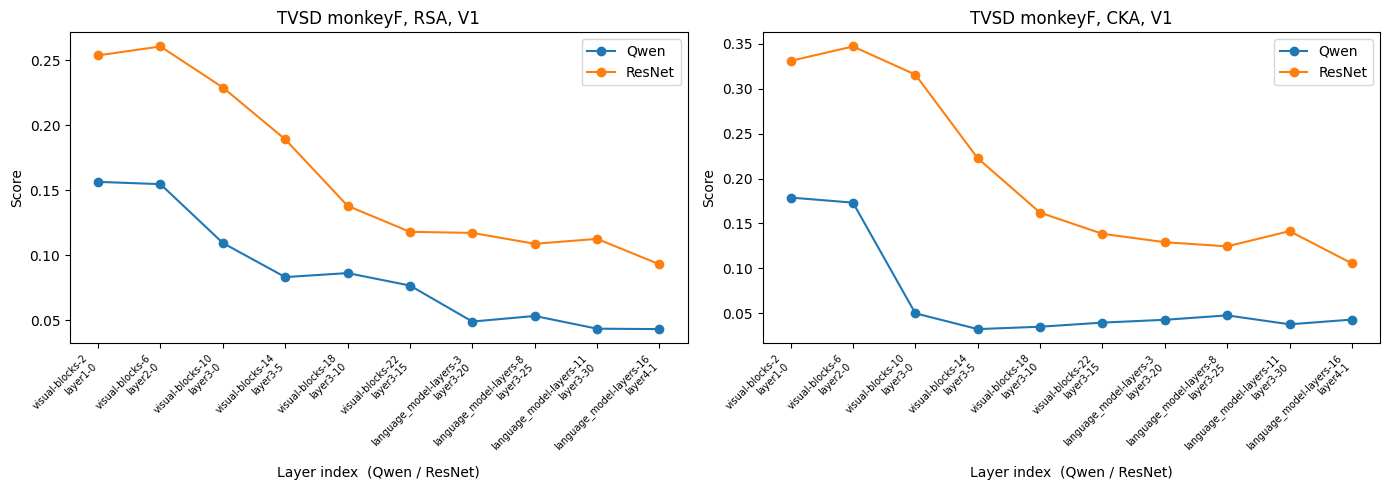

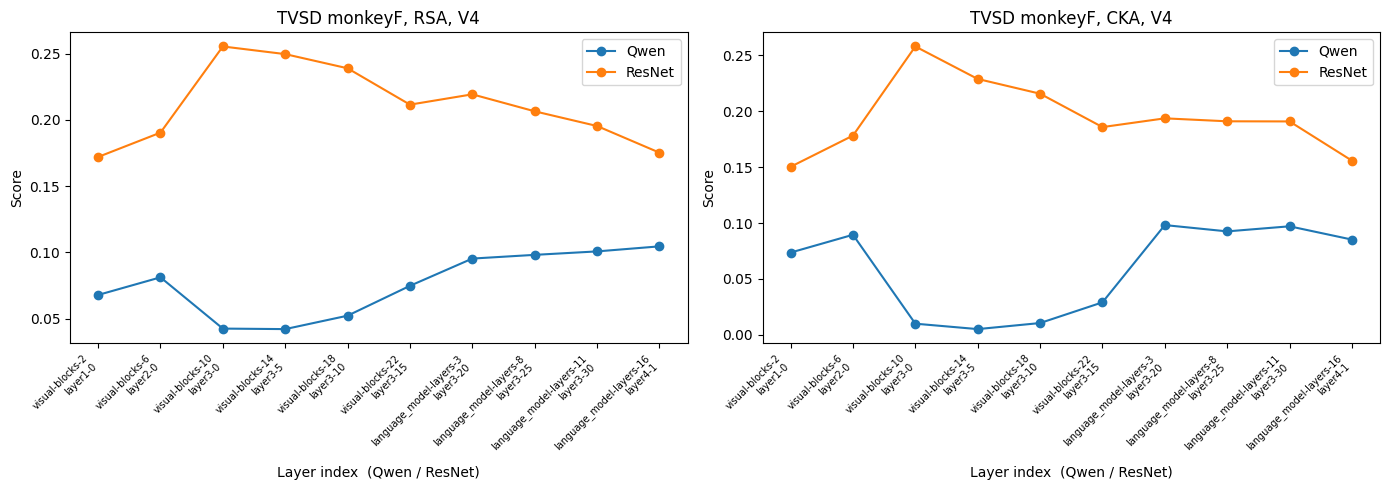

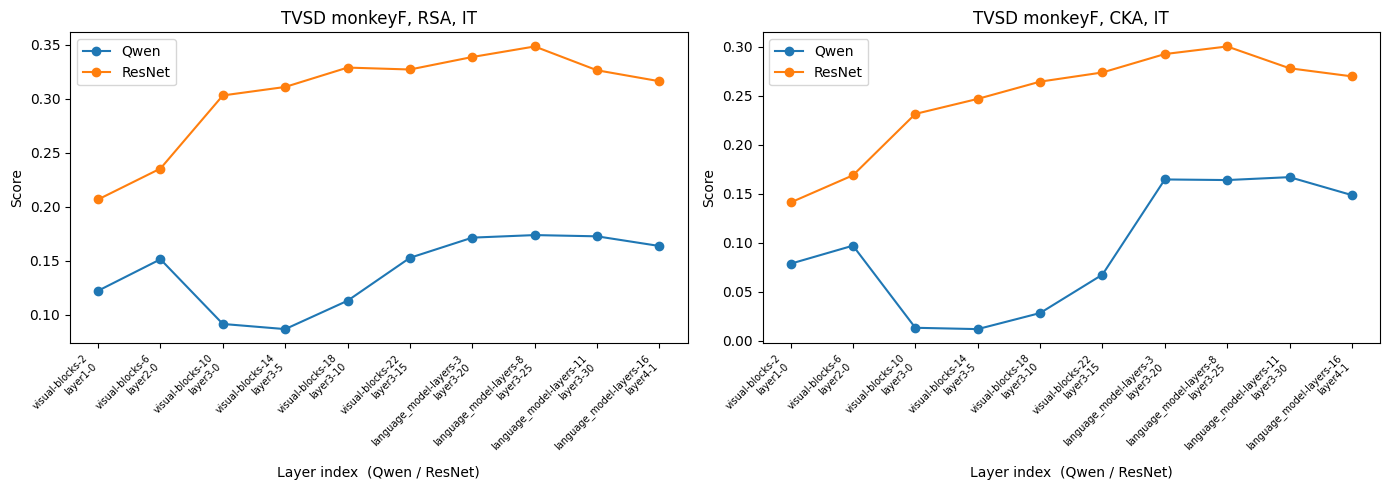

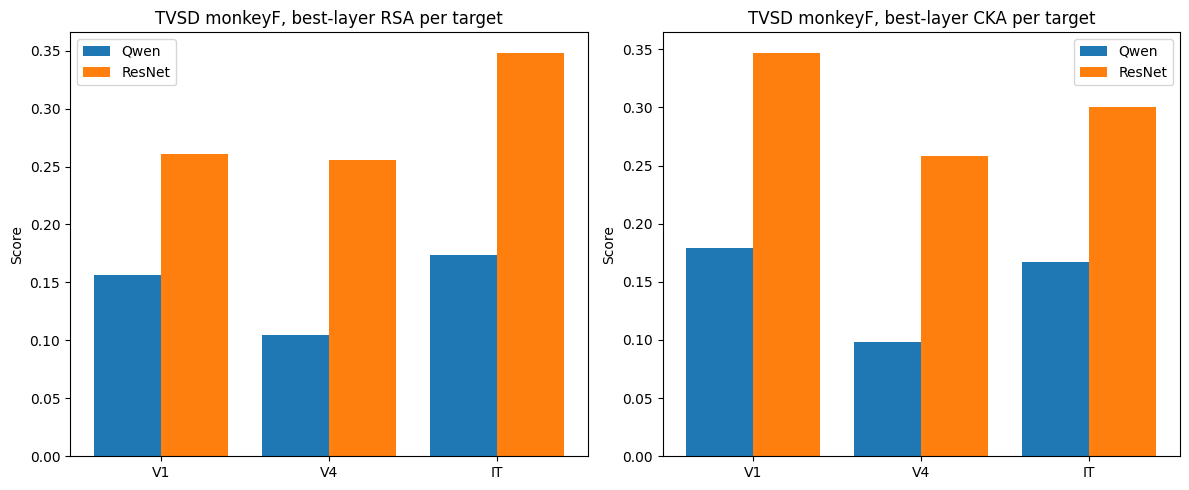

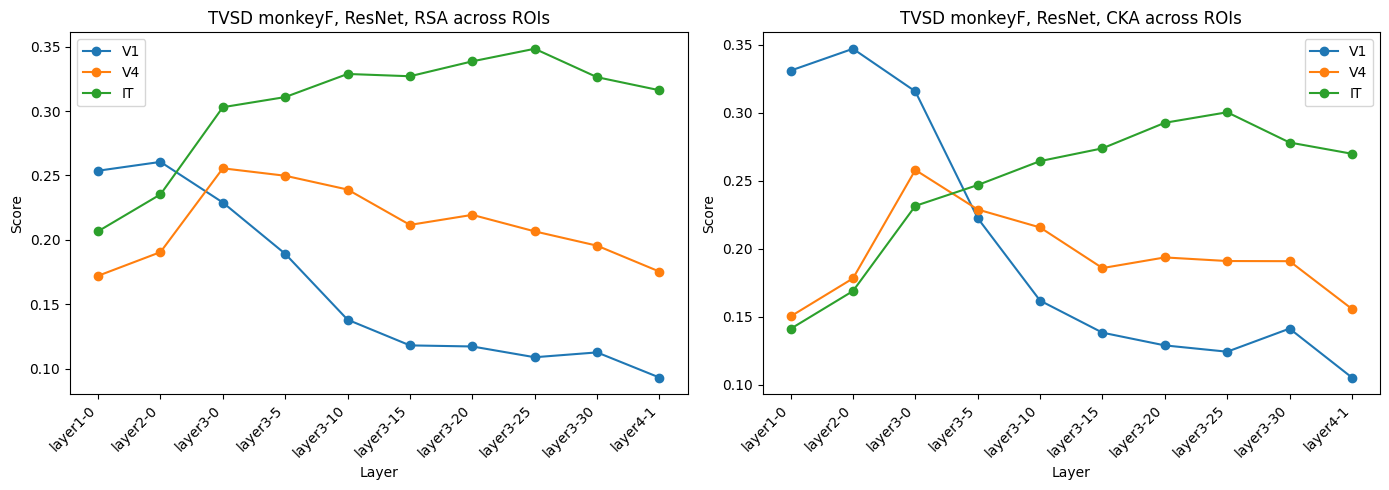

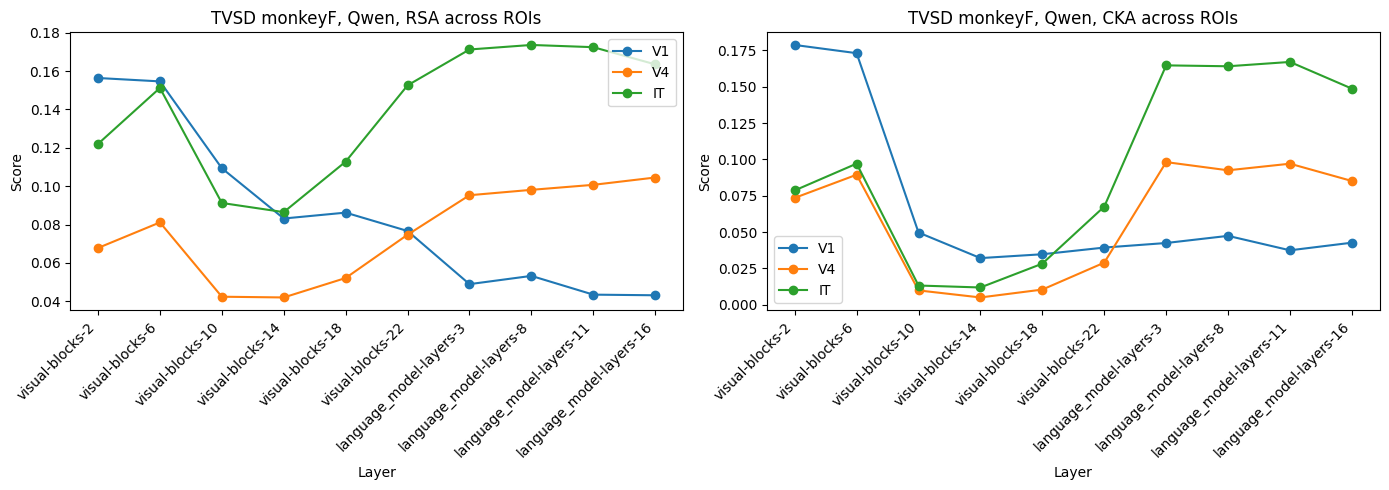

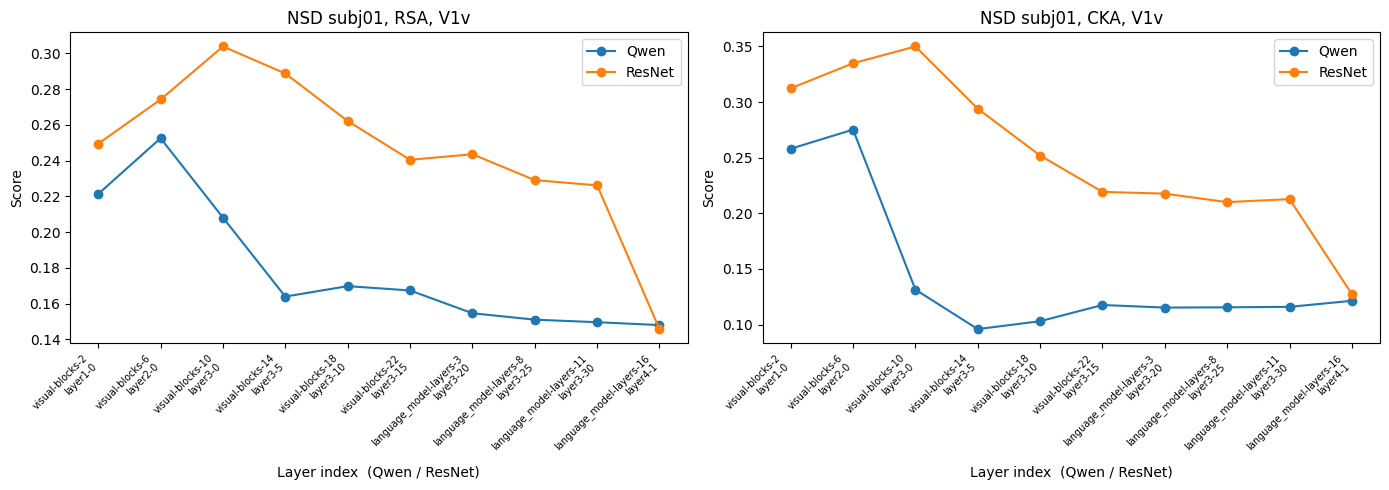

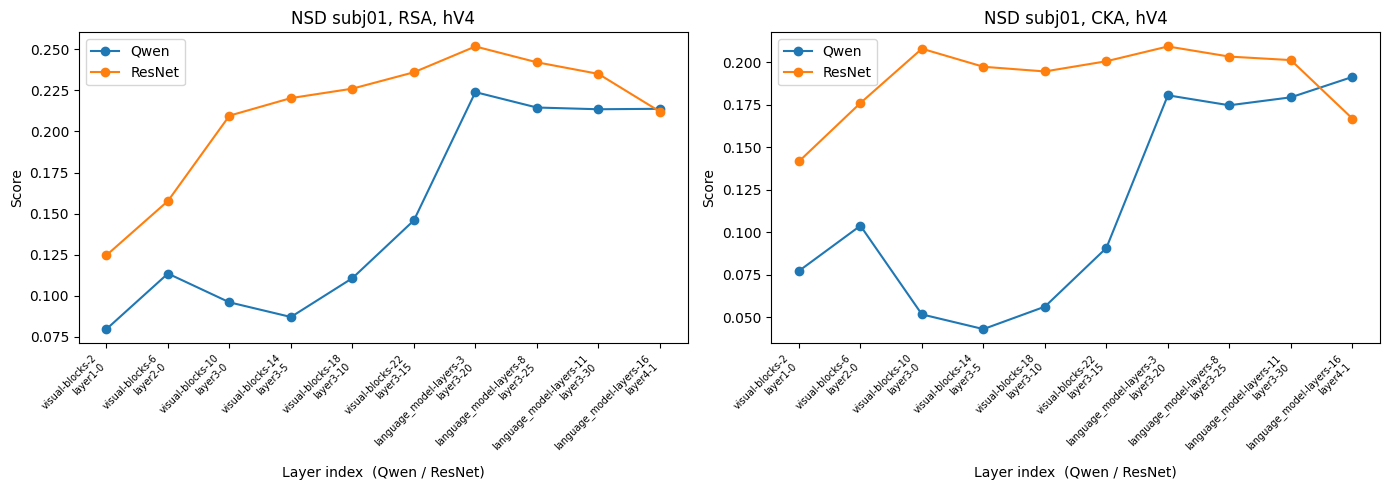

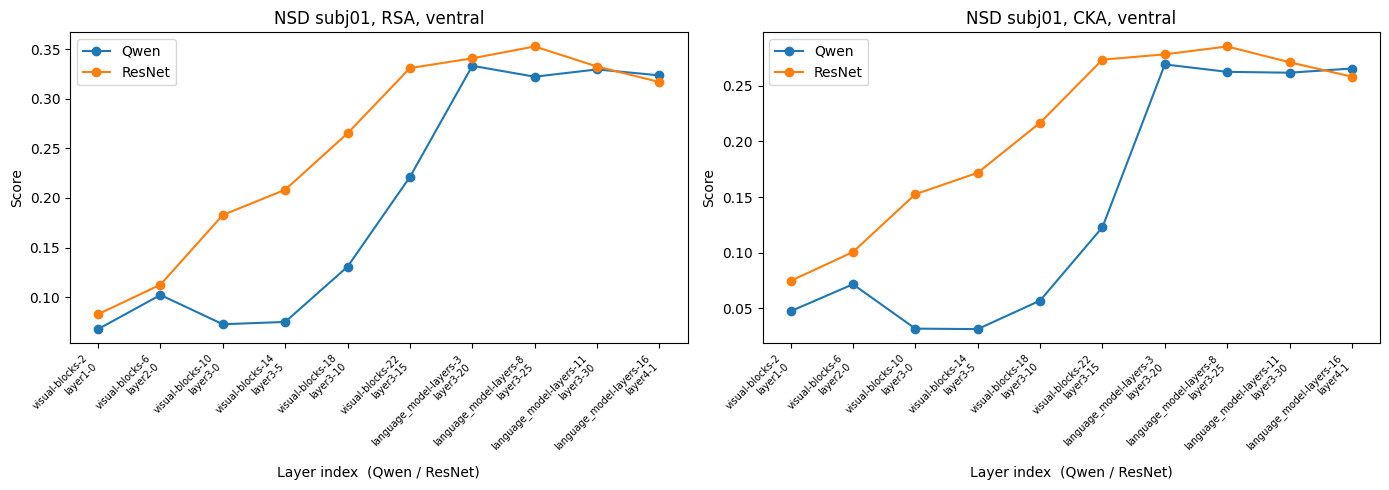

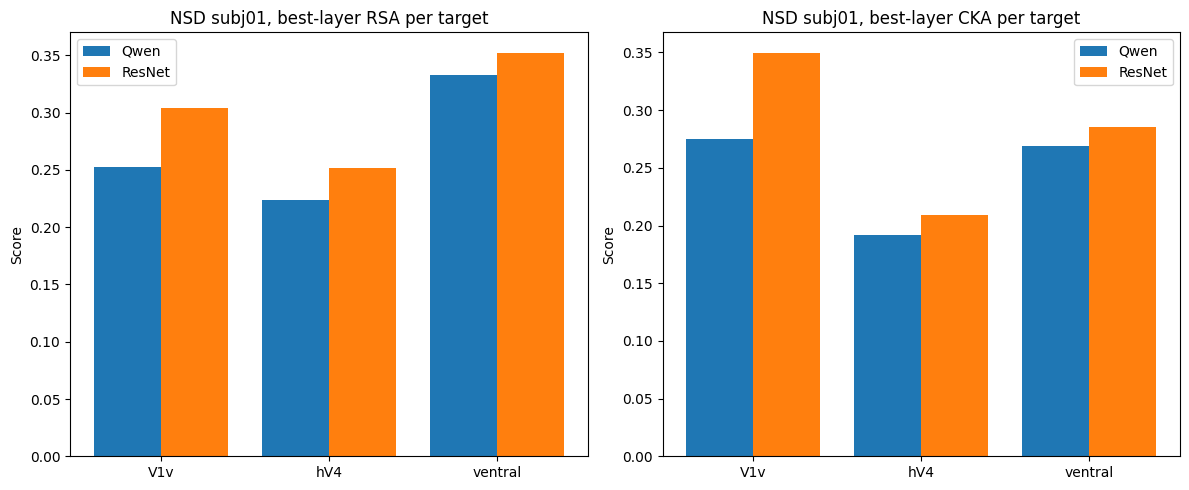

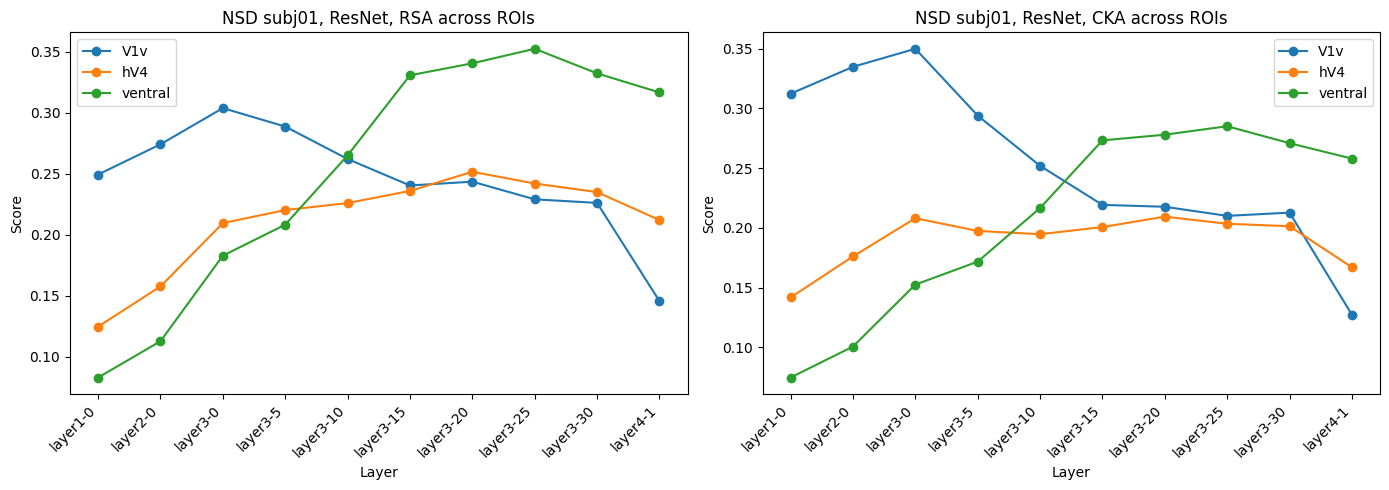

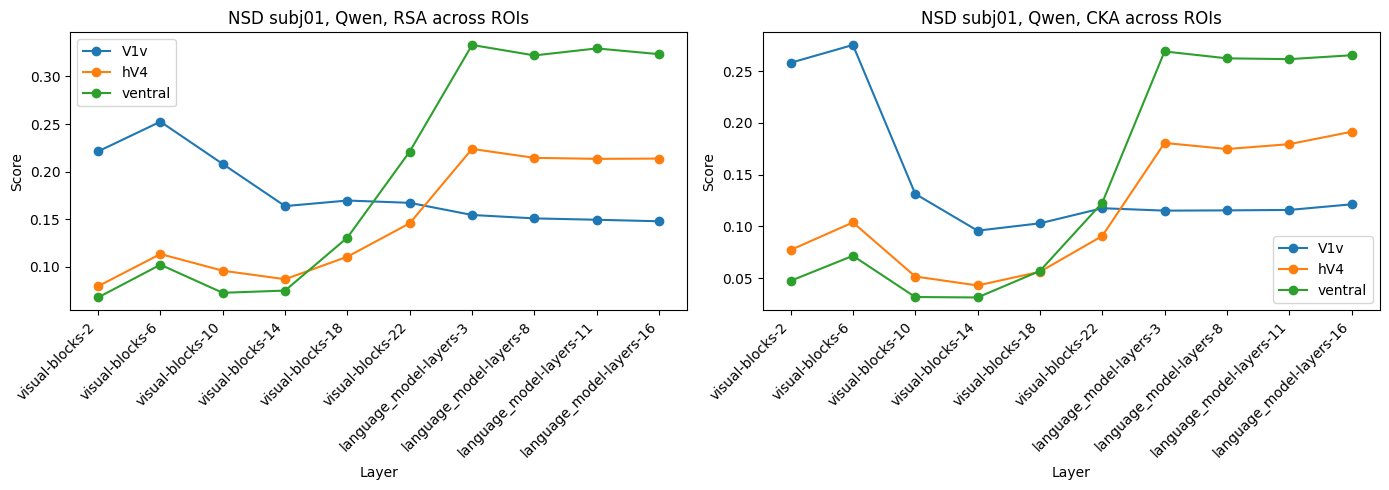

=== TVSD best layers ===
 model target metric                    layer    score
  Qwen     IT    CKA language_model-layers-11 0.167071
  Qwen     V1    CKA          visual-blocks-2 0.178757
  Qwen     V4    CKA  language_model-layers-3 0.098150
ResNet     IT    CKA                layer3-25 0.300511
ResNet     V1    CKA                 layer2-0 0.347218
ResNet     V4    CKA                 layer3-0 0.258056
  Qwen     IT    RSA  language_model-layers-8 0.173596
  Qwen     V1    RSA          visual-blocks-2 0.156374
  Qwen     V4    RSA language_model-layers-16 0.104508
ResNet     IT    RSA                layer3-25 0.348368
ResNet     V1    RSA                 layer2-0 0.260490
ResNet     V4    RSA                 layer3-0 0.255510

=== NSD best layers ===
 model  target metric                    layer    score
  Qwen     V1v    CKA          visual-blocks-6 0.275268
  Qwen     hV4    CKA language_model-layers-16 0.191468
  Qwen ventral    CKA  language_model-layers-3 0.269004
ResNet     

In [2]:
# ============ TVSD: layer-wise + model comparison + ROI hierarchy ============
results_tvsd = compare_models_and_targets(
    models_features={"ResNet": resnet_layers_tvsd, "Qwen": qwen_layers_tvsd},
    target_responses=tvsd_rois,
)
df_tvsd = scores_to_dataframe(results_tvsd)

# Layer-wise alignment (deliverables 1 & 2): both models on same axes per ROI
for roi in ["V1", "V4", "IT"]:
    plot_layerwise_alignment(
        df_tvsd, target=roi, title_prefix="TVSD monkeyF",
        save_path=f"figures/2_3_tvsd_layerwise_{roi}.png",
    )
    plt.show()

# Direct head-to-head model comparison (deliverable 3): best-layer score per ROI
plot_model_comparison(
    df_tvsd, targets=["V1", "V4", "IT"],
    title_prefix="TVSD monkeyF",
    save_path="figures/2_3_tvsd_model_comparison.png",
)
plt.show()

# Per-model ROI hierarchy (deliverable 4): ROI-wise analysis
for model in ["ResNet", "Qwen"]:
    plot_roi_alignment(
        df_tvsd, model=model, roi_order=["V1", "V4", "IT"],
        title_prefix="TVSD monkeyF",
        save_path=f"figures/2_3_tvsd_roi_{model}.png",
    )
    plt.show()

# ============ NSD: layer-wise + model comparison + ROI hierarchy ============
results_nsd = compare_models_and_targets(
    models_features={"ResNet": resnet_layers_nsd, "Qwen": qwen_layers_nsd},
    target_responses=nsd_rois,
)
df_nsd = scores_to_dataframe(results_nsd)

for roi in ["V1v", "hV4", "ventral"]:
    plot_layerwise_alignment(
        df_nsd, target=roi, title_prefix="NSD subj01",
        save_path=f"figures/2_3_nsd_layerwise_{roi}.png",
    )
    plt.show()

plot_model_comparison(
    df_nsd, targets=["V1v", "hV4", "ventral"],
    title_prefix="NSD subj01",
    save_path="figures/2_3_nsd_model_comparison.png",
)
plt.show()

for model in ["ResNet", "Qwen"]:
    plot_roi_alignment(
        df_nsd, model=model, roi_order=["V1v", "hV4", "ventral"],
        title_prefix="NSD subj01",
        save_path=f"figures/2_3_nsd_roi_{model}.png",
    )
    plt.show()

# Best-layer summary tables
print("=== TVSD best layers ===")
print(best_layer_table(df_tvsd).to_string(index=False))
print("\n=== NSD best layers ===")
print(best_layer_table(df_nsd).to_string(index=False))


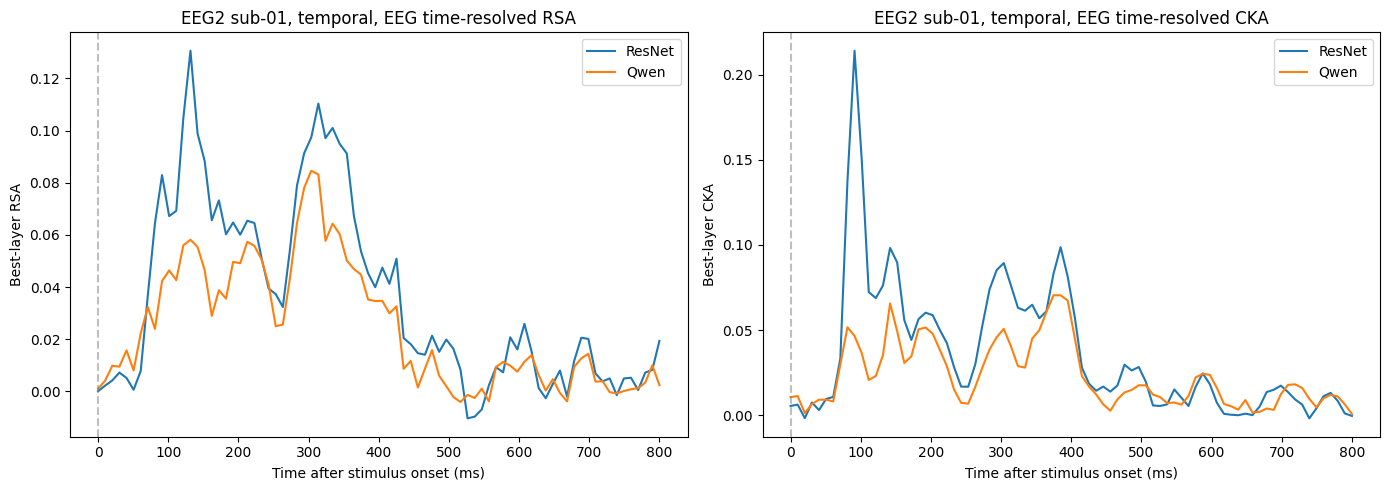

In [3]:
# ============ EEG2: time-resolved alignment (sub-01, temporal channels) =====
eeg_data, eeg_ids = load_eeg_test(EEG_PATH, subject="sub-01", region="temporal")

resnet_layers_eeg = load_features(RESNET_THINGS, eeg_ids)
qwen_layers_eeg   = load_features(QWEN_THINGS,   eeg_ids)

time_scores = compute_eeg_timeresolved(
    models_features={"ResNet": resnet_layers_eeg, "Qwen": qwen_layers_eeg},
    eeg_data=eeg_data,
)

time_ms = np.linspace(0, 800, eeg_data.shape[2])
plot_eeg_timeresolved(
    time_scores, time_ms,
    title_prefix="EEG2 sub-01, temporal",
    save_path="figures/2_3_eeg_timeresolved.png",
)
plt.show()


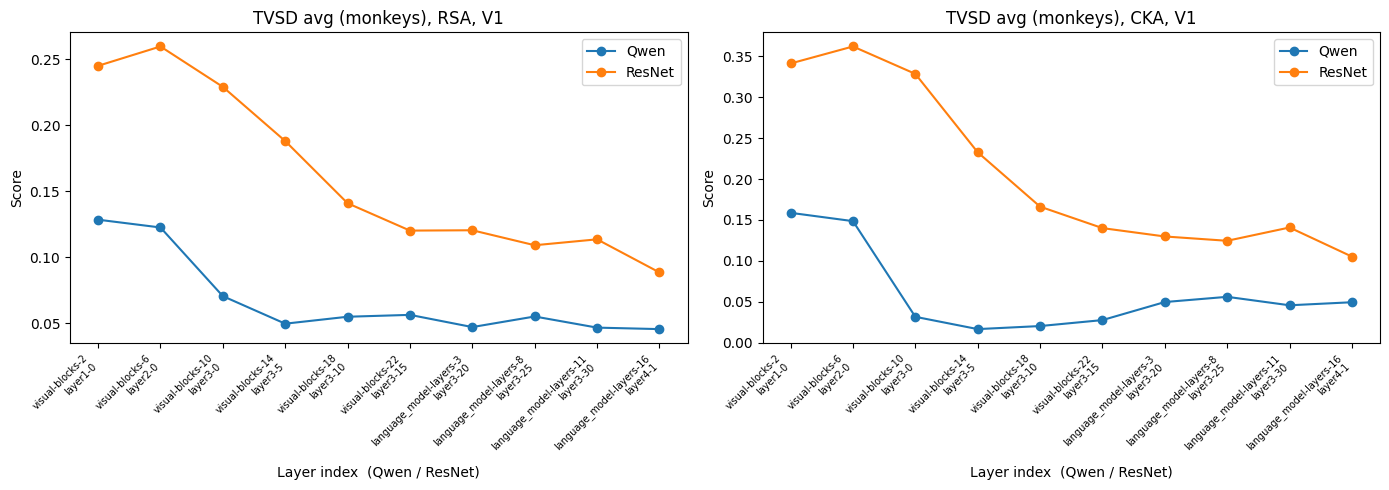

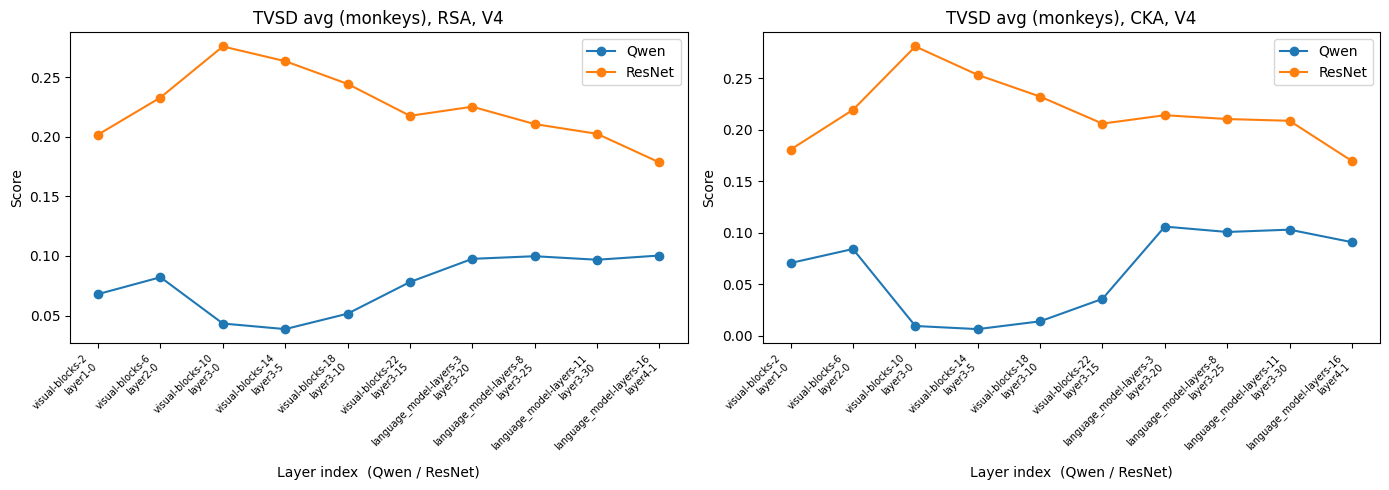

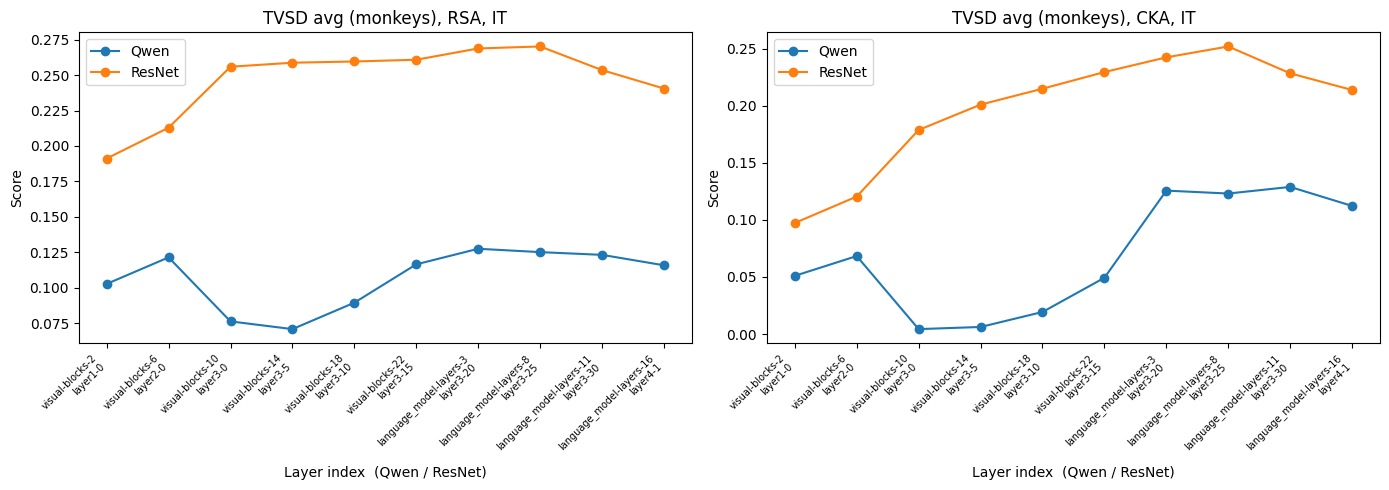

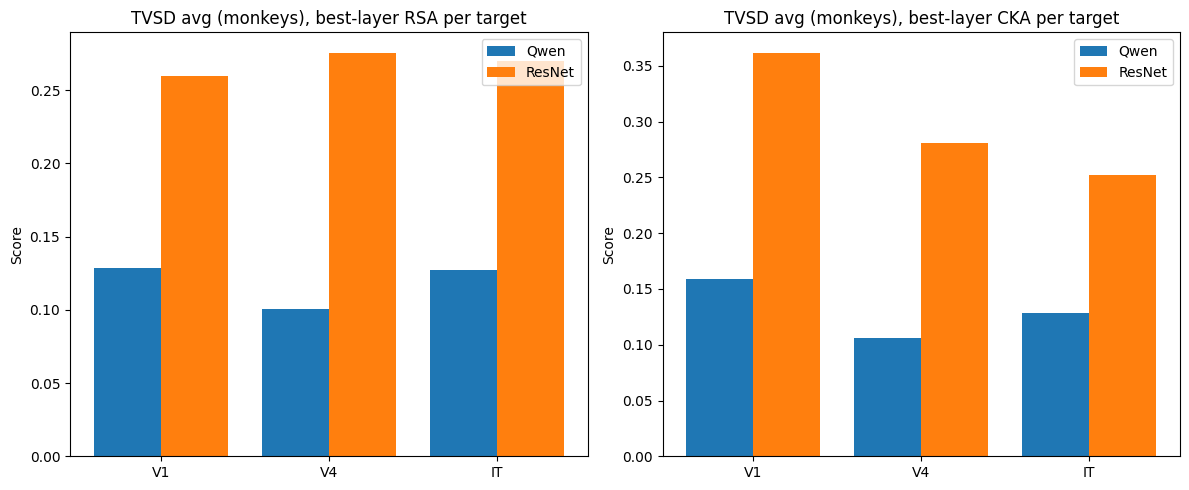

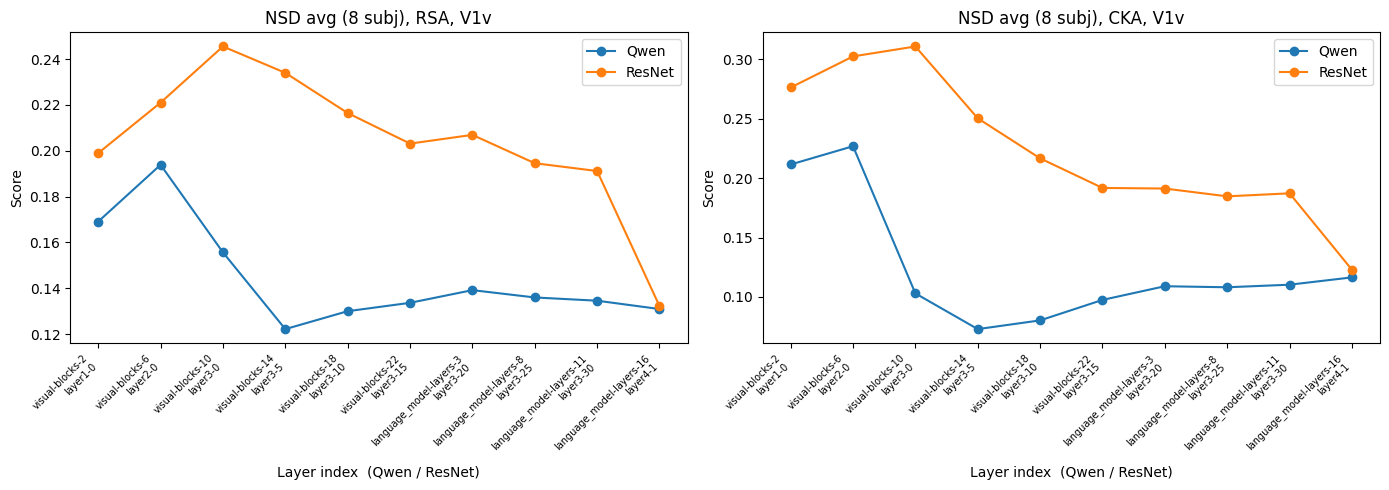

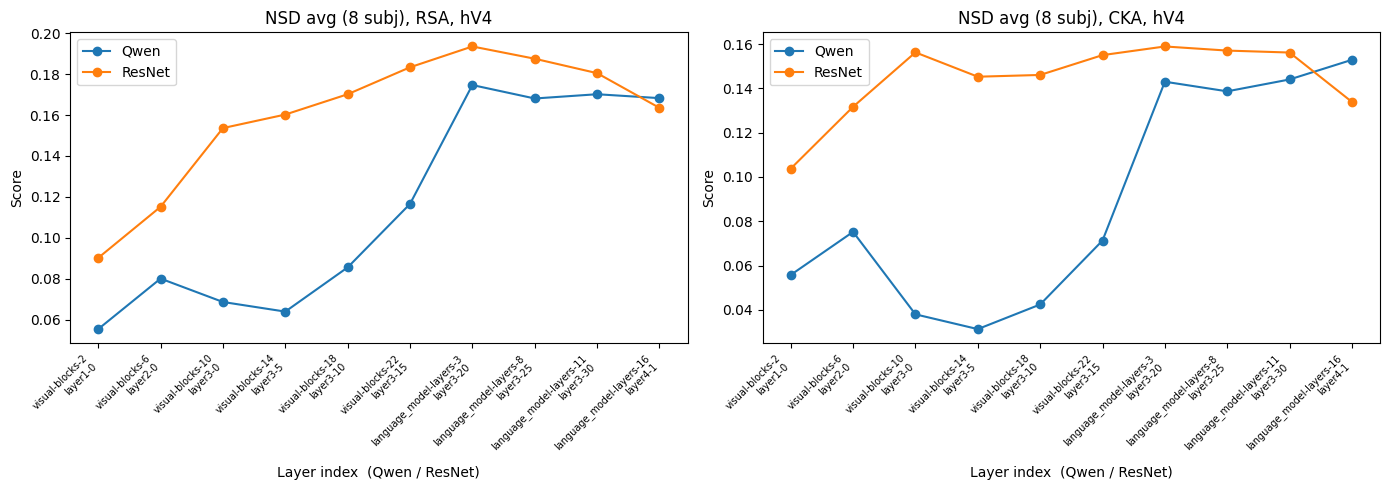

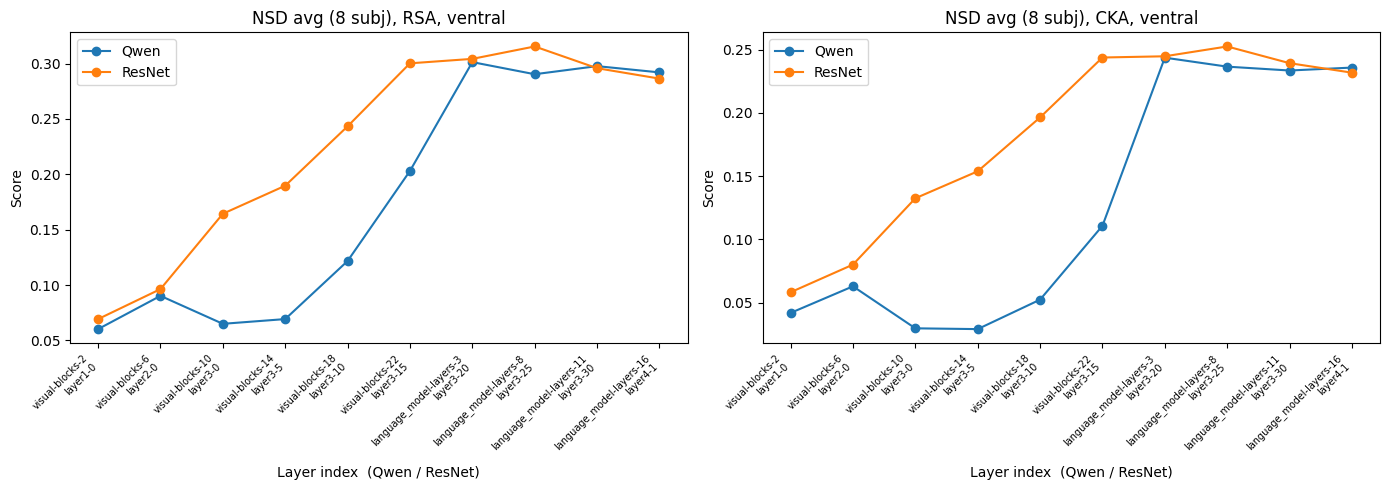

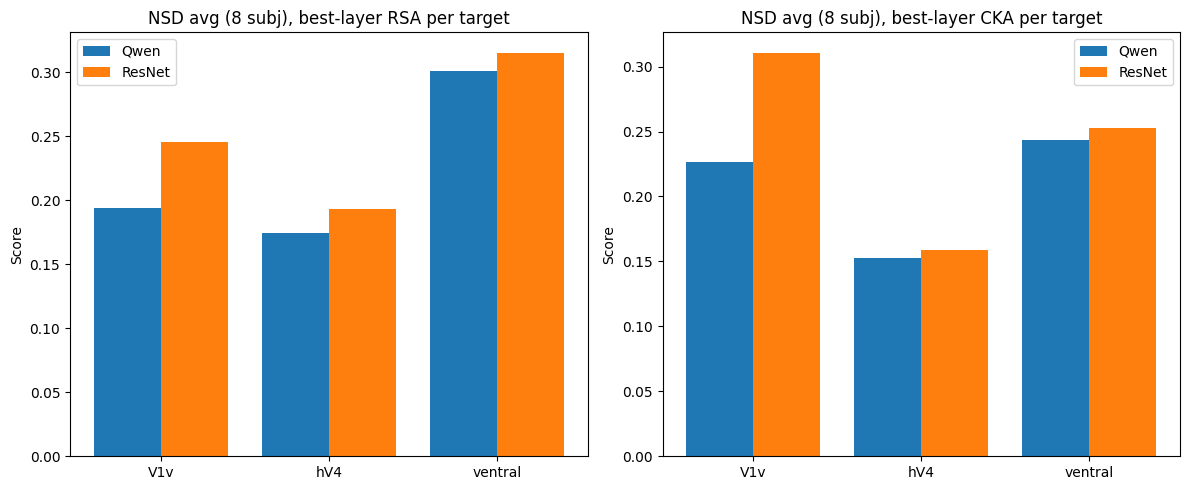

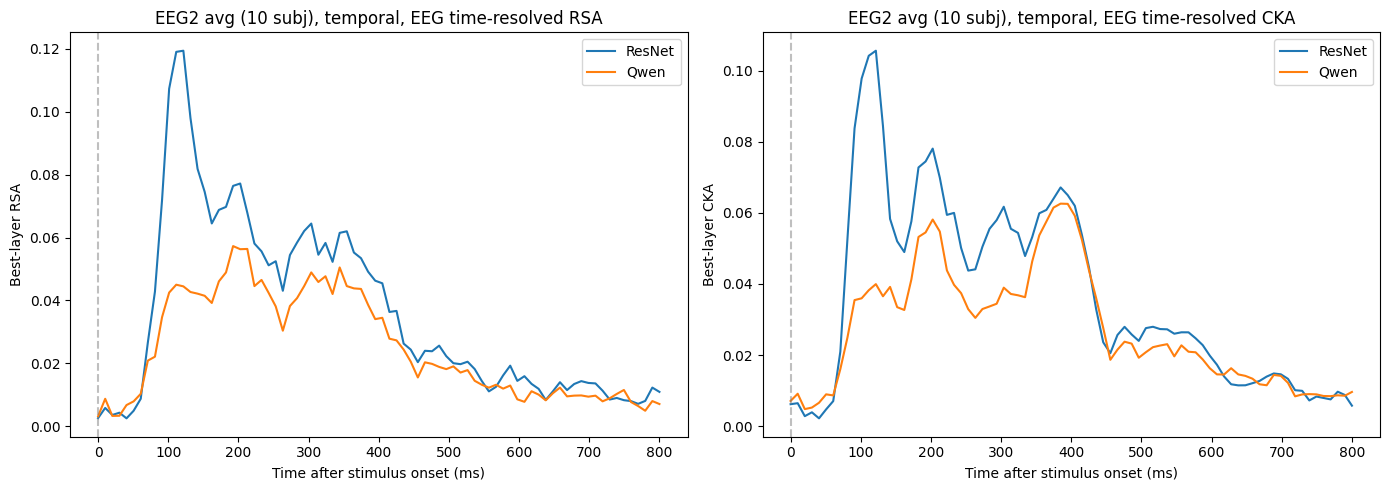

=== TVSD avg best layers ===
 model target metric                    layer    score
  Qwen     IT    CKA language_model-layers-11 0.128837
  Qwen     V1    CKA          visual-blocks-2 0.158694
  Qwen     V4    CKA  language_model-layers-3 0.105929
ResNet     IT    CKA                layer3-25 0.251856
ResNet     V1    CKA                 layer2-0 0.361972
ResNet     V4    CKA                 layer3-0 0.280970
  Qwen     IT    RSA  language_model-layers-3 0.127427
  Qwen     V1    RSA          visual-blocks-2 0.128478
  Qwen     V4    RSA language_model-layers-16 0.100392
ResNet     IT    RSA                layer3-25 0.270263
ResNet     V1    RSA                 layer2-0 0.259543
ResNet     V4    RSA                 layer3-0 0.275726

=== NSD avg best layers ===
 model  target metric                    layer    score
  Qwen     V1v    CKA          visual-blocks-6 0.226854
  Qwen     hV4    CKA language_model-layers-16 0.152891
  Qwen ventral    CKA  language_model-layers-3 0.243557
Res

In [4]:
# ============ Subject-averaged alignment ===================================
# Same RSA/CKA pipeline as above, but looped over all subjects per modality
# and averaged. Provides a more robust view than single-subject results.

# --- TVSD: average across both monkeys ---
_, df_tvsd_avg = tvsd_alignment_multisubject(
    TVSD_PATH, rois=["V1", "V4", "IT"],
    resnet_path=RESNET_THINGS, qwen_path=QWEN_THINGS,
    monkeys=["monkeyF", "monkeyN"],
)
for roi in ["V1", "V4", "IT"]:
    plot_layerwise_alignment(
        df_tvsd_avg, target=roi, title_prefix="TVSD avg (monkeys)",
        save_path=f"figures/2_3_tvsd_avg_layerwise_{roi}.png",
    )
    plt.show()
plot_model_comparison(
    df_tvsd_avg, targets=["V1", "V4", "IT"],
    title_prefix="TVSD avg (monkeys)",
    save_path="figures/2_3_tvsd_avg_model_comparison.png",
)
plt.show()

# --- NSD: average across all 8 subjects ---
_, df_nsd_avg = nsd_alignment_multisubject(
    NSD_PATH, rois=["V1v", "hV4", "ventral"],
    resnet_path=RESNET_NSD, qwen_path=QWEN_NSD,
)
for roi in ["V1v", "hV4", "ventral"]:
    plot_layerwise_alignment(
        df_nsd_avg, target=roi, title_prefix="NSD avg (8 subj)",
        save_path=f"figures/2_3_nsd_avg_layerwise_{roi}.png",
    )
    plt.show()
plot_model_comparison(
    df_nsd_avg, targets=["V1v", "hV4", "ventral"],
    title_prefix="NSD avg (8 subj)",
    save_path="figures/2_3_nsd_avg_model_comparison.png",
)
plt.show()

# --- EEG: average time-resolved scores across all 10 subjects ---
_, time_scores_avg, n_t = eeg_timeresolved_multisubject(
    EEG_PATH, region="temporal",
    resnet_path=RESNET_THINGS, qwen_path=QWEN_THINGS,
)
time_ms = np.linspace(0, 800, n_t)
plot_eeg_timeresolved(
    time_scores_avg, time_ms,
    title_prefix="EEG2 avg (10 subj), temporal",
    save_path="figures/2_3_eeg_avg_timeresolved.png",
)
plt.show()

# Best-layer summaries on the averaged data
print("=== TVSD avg best layers ===")
print(best_layer_table(df_tvsd_avg).to_string(index=False))
print("\n=== NSD avg best layers ===")
print(best_layer_table(df_nsd_avg).to_string(index=False))


---

## 2.4 Predictive alignment: linear encoding models

## Linear encoding model

In the predictive part of the project, you will map model features to neural responses using a **linear encoding model with L2 regularization (ridge regression)**.

For a stimulus $\mathbf{x}$, let $\mathbf{z}_{\ell}(\mathbf{x})$ denote the feature vector extracted from model layer $\ell$. For a given subject $s$ and neural target $r$ (for example an ROI, a group of voxels, or a set of channels / time points), the predicted neural response is

$$
\widehat{\mathbf{y}}_{r,s}(\mathbf{x})
=
W_{r,s}\,\mathbf{z}_{\ell}(\mathbf{x}) + \mathbf{b}_{r,s},
$$

where:
- $\mathbf{z}_{\ell}(\mathbf{x}) \in \mathbb{R}^{d}$ is the model feature vector,
- $\widehat{\mathbf{y}}_{r,s}(\mathbf{x}) \in \mathbb{R}^{p}$ is the predicted neural response,
- $W_{r,s} \in \mathbb{R}^{p \times d}$ is the learned linear mapping,
- $\mathbf{b}_{r,s} \in \mathbb{R}^{p}$ is a bias term.

We fit the mapping on the training split using ridge regression:

$$
\min_{W_{r,s},\,\mathbf{b}_{r,s}}
\sum_{\mathbf{x}\in\mathcal{D}_{\mathrm{train}}}
\left\|
\mathbf{y}_{r,s}(\mathbf{x}) - \widehat{\mathbf{y}}_{r,s}(\mathbf{x})
\right\|_2^2
\;+\;
\alpha \left\|W_{r,s}\right\|_F^2.
$$

Here, $\mathbf{y}_{r,s}(\mathbf{x})$ is the measured neural response, and $\alpha$ controls the strength of L2 regularization. Larger $\alpha$ penalizes large weights more strongly, which can improve generalization when the feature dimension is high. You should select $\alpha$ using only the training data, for example with a validation split or cross-validation, and then evaluate the final model on the held-out test set.

<div style="background:#eef8f4; border-left:4px solid #5b9a7a; padding:8px 12px; border-radius:6px; font-weight:700; color:#285943;">Select the required targets</div>

Use the following targets:

- **TVSD:** all ROIs
- **EEG2:** `occipital_parietal`
- **NSD:** `V1v`, `V2v`, `V3v`, `hV4`, `FFA-1`, `VWFA-1`, `PPA`, `OPA`, `EBA`

You may explore additional ROIs if you wish.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.2</strong><br>Briefly explain why these targets are scientifically interesting. Are they chosen mainly for reliability, interpretability, or both?</div>

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

For each dataset, target, model, and candidate layer:

- fit a **linear encoding model**,
- select hyperparameters without using the test split,
- evaluate on the test split.

Use iterative solvers (e.g. SGD, Adam) when needed to avoid memory issues, since `sklearn` Ridge might cause OOM.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **A clearly defined train/validation/test procedure** that does not use the test set for model selection.
2. **Linear encoding model results** for all required datasets and targets.
3. **The following predictive metrics:** Pearson correlation, noise-corrected Pearson correlation, explained variance, and noise-corrected explained variance.
4. **The following hybrid representational metrics on predicted responses:** encoding-RSA and encoding-CKA.
5. **Layer-wise plots** showing performance across candidate layers.
6. **One best-layer summary table** for the required targets.
7. **One comparison between the two models** using predictive results.
8. **One short written interpretation** in Answer box 2.3.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.3</strong><br>Which model and which layer perform best for each dataset? Summarize the main trends in a short paragraph.</div>

In [ ]:
# TODO: define train/val/test procedure
# TODO: fit linear models across layers
# TODO: compute predictive metrics
# TODO: summarize best layers and best scores

In [ ]:
from utils.predictive_plots import load_predictive_results
from utils.alignement_utils import best_layer_table
MODEL_ALIASES = {
    "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0": "ResNet",
    "Qwen3-VL-2B-Instruct": "Qwen",
}

df = load_predictive_results(
        results_dir="results",
        model_aliases=MODEL_ALIASES,
    )
best_layer_table(df)

---

## 2.5 Compare predictive and representational metrics

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

Compare the ranking of models and layers according to:

- Pearson correlation,
- explained variance,
- RSA,
- CKA.
- encoding-RSA/ encoding-CKA

Discuss whether the same layers are favored by all metrics.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One figure comparing layer or model rankings across metrics**
2. **One concrete example where two metrics agree**
3. **One concrete example where two metrics disagree**
4. **One short written interpretation** in Answer box 2.4.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.4</strong><br>Does a model that is representationally similar to the brain also predict neural responses well? Use at least one example from your results.</div>

In [ ]:
from utils.ranking_comparison import plot_ranking_comparison, plot_ranking_agreement_matrix
from utils.predictive_plots import load_predictive_results, METRIC_LABELS

# Model aliases for cleaner display
MODEL_ALIASES = {
    "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0": "ResNet",
    "Qwen3-VL-2B-Instruct": "Qwen",
}

# ROI display order per neural dataset
ROI_ORDER = {
    "TVSD": ["V1", "V4", "IT"],
    "NSD":  ["V1v", "V2v", "V3v", "hV4", "FFA-1", "VWFA-1", "PPA", "OPA", "EBA"],
    "EEG2": ["occipital_parietal"],
}

# Metrics to compare across:
metrics_to_compare = [
    "pearson_corr_mean",
    "explained_var_mean", 
    "encoding_rsa",
    "encoding_cka"
]

# Load results
df = load_predictive_results(
    results_dir="results",
    model_aliases=MODEL_ALIASES,
)

# Generate ranking comparison figures
neural_datasets = sorted(df["neural_dataset"].unique())

for nd in neural_datasets:
    sub = df[df["neural_dataset"] == nd]
    targets = ROI_ORDER.get(nd, sorted(sub["target"].unique()))
    targets = [t for t in targets if t in sub["target"].unique()]
    
    print(f"=== Ranking Comparisons for {nd} ===")
    
    # (1) Layer-wise ranking comparison per ROI
    for roi in targets:
        save = f"figures/2_5_{nd}_ranking_comparison_{roi}.png"
        print(f"  ranking comparison {roi} ...", end=" ")
        plot_ranking_comparison(
            sub, target=roi, neural_dataset=nd,
            metrics=metrics_to_compare,
            title_prefix=nd,
            save_path=save,
        )
        plt.close()
        print("saved")
    
    # (2) Best-layer agreement matrix across metrics
    save = f"figures/2_5_{nd}_ranking_agreement.png"
    print(f"  ranking agreement matrix ...", end=" ")
    plot_ranking_agreement_matrix(
        sub, neural_dataset=nd,
        metrics=metrics_to_compare,
        title_prefix=nd,
        save_path=save,
    )
    plt.close()
    print("saved")
    
    print()

print("2.5 Ranking comparison figures generated.")

---

## 2.6 Relate layer hierarchy to brain hierarchy

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

Test whether deeper layers align better with higher-level neural targets.

- Does TVSD IT align with deeper layers than V1?
- Do higher-level NSD regions prefer later layers?
- For EEG, are particular time windows associated with later layers?

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include one of the following analyses:

1. **A heatmap of layer × ROI**
2. **A ranked-layer plot by ROI**
3. **A time-resolved EEG layer comparison**

You must also include a short written conclusion in Answer box 2.5 stating whether the results support a hierarchy correspondence.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.5</strong><br>Is there evidence for a correspondence between model depth and neural hierarchy? State your conclusion clearly and support it with results.</div>

In [ ]:
# TODO: compare layers across ROIs / time windows
# TODO: create hierarchy figure(s)

---

## 2.7 Compare the two feature extractors

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

Compare **Qwen3-VL-2B-Instruct** and **Adv-ResNet152** across datasets, ROIs, layers, and metrics.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One summary figure comparing Qwen3-VL-2B-Instruct and Adv-ResNet152**
2. **One table of best scores across datasets and targets**
3. **One short written interpretation** in Answer box 2.6.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.6</strong><br>Does the vision-language model provide a clear advantage over the CNN? Is that advantage consistent across modalities and targets?</div>

In [ ]:
# TODO: aggregate results across both models
# TODO: create summary comparison figure/table

---

# 3. Open-Ended Research

So far you have explored a simple encoding model with a linear readout from a single layer per subject/ROI. In this section, you will extend the baseline pipeline in one clearly defined direction. The goal is to explore a meaningful extension that goes beyond the standard linear readout and to evaluate whether it provides a practically meaningful improvement. Depth is more important than breadth: a focused experiment is better than a broad but shallow exploration.

Possible directions include:

- readouts shared across ROIs,
- readouts shared across subjects,
- readouts shared across modalities,
- combining multiple layers,
- low-rank readouts,
- nonlinear readouts,
- temporal readouts for EEG,
- attention-based readouts,
- cross-subject pooling.

## What you must include

1. **Question**  
   What are you testing?

2. **Motivation**  
   Why is this extension interesting?

3. **Method**  
   What did you change relative to the linear baseline?

4. **Comparison**  
   How does it compare to the baseline?

5. **Interpretation**  
   Did it help, and why might that be?

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **A clearly stated hypothesis**
2. **A short motivation for the extension**
3. **A clear description of the new method**
4. **One direct comparison against the linear baseline**
5. **At least one figure or one table summarizing the comparison**
6. **A short discussion of whether the extension helped in a practically meaningful way**

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 3</strong><br>State your hypothesis, summarize your result, and say whether the new method helped in a practically meaningful way.</div>

In [ ]:
# TODO: define extension
# TODO: implement method
# TODO: compare against linear baseline

---

# Final Discussion

End the notebook with a short final discussion.

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must address</div>

- Which dataset appeared noisiest?
- Which neural targets were most reliable?
- Which model aligned best overall?
- Which metrics were most consistent with each other?
- What was the main limitation of your analysis?
- What would you try next with more time?

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box final</strong><br>Write a concise final conclusion of 1–2 paragraphs summarizing your main findings and their limitations.</div>

In [ ]:
# No code required here unless you want to add final summary tables/figures.

---

# Report Content

Your **2-page PDF report** should tell a clear and coherent story. It does **not** need to reproduce every notebook result.

It can include:

1. **A brief dataset overview**
2. **An exploratory figure from Section 1**
3. **The EEG noise ceiling comparison**
4. **The NSD reliability visualization**
5. **One or two key brain–model alignment results from Section 2**


Rather, you should primarily focus on the open-ended extension you designed, describing:
- the motivation for your extension,
- the methods you implemented,
- the results you obtained,
- and the scientific insights you gained from it.


The report should emphasize interpretation, not just figures. Since the notebook is the main technical deliverable, the report should act as a **compressed scientific summary** of your most important findings rather than a figure dump.

---

# Detailed Grading Rubric

The project is graded out of **100 points** as follows:

- **Section 1: Inspection, Visualization, and Noise Ceiling Estimates — 20 points**
- **Section 2: Brain–Model Alignment — 20 points**
- **Section 3: Open-Ended Research — 30 points**
- **Report — 30 points**

**Section 0 is required but not graded separately.** It is treated as setup and reproducibility infrastructure for the rest of the notebook.

## Section 1 — 20 points

### 1.1 Dataset inspection — 3 points
- 1 pt: TVSD structure is correctly inspected and explained.
- 1 pt: EEG2 structure is correctly inspected and explained.
- 1 pt: NSD structure is correctly inspected and explained.

### 1.2 EEG visualization — 4 points
- 1 pt: example EEG time-course plot is present and readable.
- 1 pt: channel × time heatmap is present and readable.
- 1 pt: provided EEG noise ceiling visualization is present and readable.
- 1 pt: written interpretation identifies informative time windows or channel groups.

### 1.3 EEG noise ceiling estimation — 7 points
- 2 pts: variance-based estimator is implemented correctly.
- 2 pts: split-half estimator is implemented correctly.
- 1 pt: required summary visualizations are included.
- 1 pt: comparison to stored EEG noise ceilings is shown clearly.
- 1 pt: Answer box 1.3 interprets similarities and differences between estimators.

### 1.4 Statistical comparison of EEG noise ceilings — 3 points
- 1 pt: quantitative comparison table is present.
- 1 pt: statistical test or formal comparison is appropriate and correctly interpreted.
- 1 pt: final conclusion is clearly justified.

### 1.5 NSD reliability visualization — 3 points
- 1 pt: ncsnr is correctly converted and visualized on cortex.
- 1 pt: parcel overlay or parcel-wise summary is included.
- 1 pt: Answer box 1.5 correctly interprets reliable and unreliable regions.

## Section 2 — 20 points

### 2.1 RSA implementation — 3 points
- 1 pt: RDM computation is correct.
- 1 pt: RDM comparison is correct.
- 1 pt: implementation is used properly in later analyses.

### 2.2 Unbiased linear CKA implementation — 3 points
- 2 pts: unbiased linear CKA is implemented correctly.
- 1 pt: implementation is used properly in later analyses.

### 2.3 Representational analyses across layers, models, and targets — 4 points
- 1 pt: layer-wise RSA results are reported clearly.
- 1 pt: layer-wise CKA results are reported clearly.
- 1 pt: a model comparison is included.
- 1 pt: ROI-wise or time-resolved analysis is included and interpreted.

### 2.4 Predictive alignment with linear encoding models — 6 points
- 1 pt: required targets are selected and described correctly.
- 2 pts: train/validation/test procedure and ridge fitting are correct.
- 1 pt: required predictive metrics are reported correctly.
- 1 pt: encoding-RSA and encoding-CKA are reported correctly.
- 1 pt: best-layer summary and model comparison are included.

### 2.5 Compare predictive and representational metrics — 2 points
- 1 pt: ranking comparison figure is present and informative.
- 1 pt: agreement and disagreement between metrics are discussed clearly.

### 2.6 Layer hierarchy vs brain hierarchy — 1 point
- 1 pt: at least one hierarchy analysis is included and interpreted correctly.

### 2.7 Compare the two feature extractors — 1 point
- 1 pt: final comparison between Qwen3-VL and Adv-ResNet is clear and supported by results.

## Section 3 — 30 points

### Research question and motivation — 5 points
- 2 pts: research question is clear and focused.
- 3 pts: motivation is scientifically sensible and well connected to the baseline project.

### Method and implementation — 10 points
- 4 pts: the extension is described clearly.
- 4 pts: the method is implemented correctly.
- 2 pts: the design remains focused and technically appropriate for the project scope.

### Baseline comparison and evaluation — 10 points
- 4 pts: the comparison to the linear baseline is fair.
- 3 pts: at least one figure or table communicates the comparison clearly.
- 3 pts: evaluation supports the stated conclusion.

### Interpretation and limitations — 5 points
- 3 pts: the student explains whether the method helped in a practically meaningful way.
- 2 pts: limitations or caveats are acknowledged.

## Report — 30 points

### Structure and clarity — 6 points
- clear organization, readable flow, and concise scientific writing.

### Selection of results — 6 points
- the report focuses on the strongest and most relevant results rather than trying to include everything.

### Methodological correctness — 6 points
- metrics, comparisons, and claims are described accurately.

### Interpretation and synthesis — 6 points
- the report explains what the results mean and ties them back to the project goals.

### Figure quality and presentation — 6 points
- figures are readable, labeled, well-chosen, and integrated into the narrative.

## Important grading note

A submission that is technically correct but poorly interpreted will lose points. A submission with good intuition but missing required analyses will also lose points. The strongest submissions will be both **correct** and **scientifically well explained**.

---

# Final Checklist Before Submission

Before submitting, make sure that:

- group information is filled in,
- the notebook runs from top to bottom,
- all notebook outputs are cleared,
- figures have readable titles and labels,
- written answers are included in the answer boxes,
- the zip archive name follows the required format,
- no large unnecessary files are included.

---

# References

Use the references below when you need scientific context for the datasets, models, and analysis methods.

## Datasets

- Papale et al. (2025) — *An extensive dataset of spiking activity to reveal the syntax of the ventral stream*
- Gifford et al. (2022) — *A large and rich EEG dataset for modeling human visual object recognition*
- Allen et al. (2022) — *A massive 7T fMRI dataset to bridge cognitive neuroscience and artificial intelligence*
- van Bree, Styrnal, and Hebart (2025) — *How Much Variance Does Your Model Explain? A Clarifying Note On The Use Of Split-Half Reliability For Computing Noise Ceilings*

## Models

- Wong et al. (2020) — *Fast is better than free: Revisiting adversarial training*
- He et al. (2016) — *Deep Residual Learning for Image Recognition*
- Bai et al. (2025) — *Qwen3-VL Technical Report*

## Alignment and encoding

- Conwell et al. (2024) — *A large-scale examination of inductive biases shaping high-level visual representation in brains and machines*
- Gokce and Schrimpf (2025) — *Scaling Laws for Task-Optimized Models of the Primate Visual Ventral Stream*

Use these references selectively. You are not expected to read everything in full.